# Cuaderno PySpark definitivo — Persona 4

**Proyecto:** análisis de precios de carburantes en Europa, con foco especial en España.  
**Objetivo del cuaderno:** explotar el modelo dimensional final con PySpark, construir el cubo analítico y responder preguntas de negocio mediante operaciones OLAP, consultas y visualizaciones.

Este notebook corresponde a la parte final del proyecto: no vuelve a hacer el ETL, sino que parte de los CSV finales ya generados en `data/final/` y subidos a GitHub. A partir de esas tablas se construye el cubo `cubo_carburantes`, que permite analizar precios por **tiempo, país, región, producto, fuente e indicadores macroeconómicos**.

### Checklist de requisitos cubiertos

- Lectura de CSV finales desde GitHub mediante URL `raw`.
- Conversión a Spark DataFrames.
- Validación inicial de tablas y esquemas.
- Registro de vistas temporales SQL.
- Construcción del cubo dimensional mediante joins entre FACT y dimensiones.
- Operaciones OLAP explícitas: `rollup`, drill-down, slice, dice, pivot, cube y window function.
- Preguntas de negocio con consulta, gráfico e interpretación.
- Exportación de tablas y gráficos en `outputs/tablas/` y `outputs/graficos/`.

### Narrativa del análisis

El análisis va de lo general a lo concreto: primero se comprueba cómo se comporta España frente a Europa, después se comparan países y productos, y finalmente se profundiza en factores explicativos como fiscalidad, PIB, dependencia energética y el shock energético de 2022.


## 1. Instalación, librerías y estilo visual

Esta sección prepara el entorno de trabajo. Se instala PySpark para simular procesamiento distribuido en Colab, se importan librerías de análisis y visualización, y se definen funciones auxiliares para guardar tablas y gráficos.


In [1]:
!pip install pyspark findspark plotly scikit-learn requests -q

In [2]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window

import os, io, zipfile, requests, builtins
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split

os.makedirs("outputs/graficos", exist_ok=True)
os.makedirs("outputs/tablas", exist_ok=True)

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["font.size"] = 10

COL_SP = "#E63946"       # España
COL_EU = "#457B9D"       # Europa
COL_ACCENT = "#F4A261"   # Naranja
COL_GREEN = "#2A9D8F"    # Verde
COL_DARK = "#264653"     # Azul oscuro
COL_PURPLE = "#7B2CBF"   # Morado
COL_GREY = "#ADB5BD"     # Gris
COL_GOLD = "#E9C46A"     # Dorado

def guardar_tabla(df, nombre):
    ruta = f"outputs/tablas/{nombre}"
    df.to_csv(ruta, index=False)
    print(f"Tabla guardada en: {ruta}")

def guardar_grafico(nombre):
    ruta = f"outputs/graficos/{nombre}"
    plt.savefig(ruta, dpi=160, bbox_inches="tight")
    print(f"Gráfico guardado en: {ruta}")

spark = SparkSession.builder \
    .appName("CuboCarburantesBigData_Definitivo") \
    .config("spark.driver.memory", "2g") \
    .getOrCreate()

spark.sparkContext.setLogLevel("WARN")
print("Spark iniciado correctamente")

Spark iniciado correctamente


## 2. Lectura de CSV finales desde GitHub

Los datos de entrada del cuaderno son los CSV finales del modelo estrella. Se leen directamente desde GitHub, lo que hace que el notebook sea reproducible y no dependa de subir archivos manualmente a Colab.

**Idea clave:** si el repositorio está público y los CSV están en `data/final/`, cualquier miembro del grupo o el profesor puede ejecutar este cuaderno desde cero.


In [3]:
BASE = "https://raw.githubusercontent.com/nataliablancot-cyber/Trabajo-Big-Data-/main/data/final/"

fact_pd = pd.read_csv(BASE + "fact_precios_carburante.csv")
dim_tiempo_pd = pd.read_csv(BASE + "dim_tiempo.csv")
dim_geo_pd = pd.read_csv(BASE + "dim_geografia.csv")
dim_producto_pd = pd.read_csv(BASE + "dim_producto.csv")
dim_indicadores_pd = pd.read_csv(BASE + "dim_indicadores.csv")
dim_fuente_pd = pd.read_csv(BASE + "dim_fuente.csv")

print("CSV finales cargados desde GitHub")
print("Fact:", fact_pd.shape)
print("Dim tiempo:", dim_tiempo_pd.shape)
print("Dim geografía:", dim_geo_pd.shape)
print("Dim producto:", dim_producto_pd.shape)
print("Dim indicadores:", dim_indicadores_pd.shape)
print("Dim fuente:", dim_fuente_pd.shape)

CSV finales cargados desde GitHub
Fact: (55093, 13)
Dim tiempo: (1047, 8)
Dim geografía: (27, 5)
Dim producto: (2, 6)
Dim indicadores: (553, 5)
Dim fuente: (4, 7)


## 3. Conversión a Spark DataFrames y validación inicial

Aquí se convierten las tablas de pandas a Spark DataFrames y se comprueba que las dimensiones y la tabla de hechos se han cargado correctamente.

**Validación esperada:** revisar número de filas, nombres de columnas y tipos de dato. Esta parte es importante porque cualquier error en claves o columnas afectaría al cubo y a todas las consultas posteriores.


In [4]:
fact = spark.createDataFrame(fact_pd)
dim_tiempo = spark.createDataFrame(dim_tiempo_pd)
dim_geo = spark.createDataFrame(dim_geo_pd)
dim_producto = spark.createDataFrame(dim_producto_pd)
dim_indicadores = spark.createDataFrame(dim_indicadores_pd)
dim_fuente = spark.createDataFrame(dim_fuente_pd)

print("Conteo de registros")
print("Fact:", fact.count())
print("Dim tiempo:", dim_tiempo.count())
print("Dim geografía:", dim_geo.count())
print("Dim producto:", dim_producto.count())
print("Dim indicadores:", dim_indicadores.count())
print("Dim fuente:", dim_fuente.count())

fact.printSchema()
fact.show(5)
dim_tiempo.show(5)
dim_geo.show(5)
dim_producto.show(5)
dim_indicadores.show(5)
dim_fuente.show(5)

Conteo de registros
Fact: 55093
Dim tiempo: 1047
Dim geografía: 27
Dim producto: 2
Dim indicadores: 553
Dim fuente: 4
root
 |-- sk_hecho: long (nullable = true)
 |-- sk_tiempo: long (nullable = true)
 |-- sk_geografia: long (nullable = true)
 |-- sk_producto: long (nullable = true)
 |-- sk_indicador: long (nullable = true)
 |-- sk_fuente: long (nullable = true)
 |-- precio_eur_litro: double (nullable = true)
 |-- impuesto_eur_litro: double (nullable = true)
 |-- precio_sin_impuesto: double (nullable = true)
 |-- pct_impuesto: double (nullable = true)
 |-- tasa_impuesto_pct: double (nullable = true)
 |-- source_id: string (nullable = true)
 |-- load_timestamp: string (nullable = true)

+--------+---------+------------+-----------+------------+---------+----------------+------------------+-------------------+------------+-----------------+-----------------+--------------------+
|sk_hecho|sk_tiempo|sk_geografia|sk_producto|sk_indicador|sk_fuente|precio_eur_litro|impuesto_eur_litro|precio_

## 4. Registro de vistas temporales SQL

Se registran las tablas como vistas temporales para poder utilizar Spark SQL. Esto permite mezclar el enfoque de DataFrames con consultas SQL, que es útil para análisis OLAP.


In [5]:
fact.createOrReplaceTempView("fact_precios")
dim_tiempo.createOrReplaceTempView("dim_tiempo")
dim_geo.createOrReplaceTempView("dim_geografia")
dim_producto.createOrReplaceTempView("dim_producto")
dim_indicadores.createOrReplaceTempView("dim_indicadores")
dim_fuente.createOrReplaceTempView("dim_fuente")
print("Vistas temporales registradas")

Vistas temporales registradas


## 5. Construcción del cubo dimensional

El cubo se construye uniendo la tabla de hechos con las dimensiones de tiempo, geografía, producto, indicadores y fuente.

**Pregunta técnica:** ¿qué aporta el cubo frente a una tabla plana?

**Respuesta:** permite analizar una misma métrica, el precio del carburante, desde varias perspectivas: año, país, región, producto, fuente e indicadores macroeconómicos. Esta es la base del análisis BI del proyecto.


In [6]:
# Renombramos campos conflictivos para evitar duplicidades al hacer joins
_dim_ind = dim_indicadores
if "country_code" in _dim_ind.columns:
    _dim_ind = _dim_ind.withColumnRenamed("country_code", "country_code_indicador")
if "year" in _dim_ind.columns:
    _dim_ind = _dim_ind.withColumnRenamed("year", "year_indicador")

_dim_fuente = dim_fuente
if "nombre" in _dim_fuente.columns:
    _dim_fuente = _dim_fuente.withColumnRenamed("nombre", "nombre_fuente")

cubo = fact \
    .join(dim_tiempo, "sk_tiempo", "left") \
    .join(dim_geo, "sk_geografia", "left") \
    .join(dim_producto, "sk_producto", "left") \
    .join(_dim_ind, "sk_indicador", "left") \
    .join(_dim_fuente, "sk_fuente", "left")

if "fecha" in cubo.columns:
    cubo = cubo.withColumn("fecha", F.to_date("fecha"))

cubo.createOrReplaceTempView("cubo_carburantes")
print("Cubo construido. Filas:", cubo.count())
cubo.printSchema()
cubo.show(10)

Cubo construido. Filas: 55093
root
 |-- sk_fuente: long (nullable = true)
 |-- sk_indicador: long (nullable = true)
 |-- sk_producto: long (nullable = true)
 |-- sk_geografia: long (nullable = true)
 |-- sk_tiempo: long (nullable = true)
 |-- sk_hecho: long (nullable = true)
 |-- precio_eur_litro: double (nullable = true)
 |-- impuesto_eur_litro: double (nullable = true)
 |-- precio_sin_impuesto: double (nullable = true)
 |-- pct_impuesto: double (nullable = true)
 |-- tasa_impuesto_pct: double (nullable = true)
 |-- source_id: string (nullable = true)
 |-- load_timestamp: string (nullable = true)
 |-- fecha: date (nullable = true)
 |-- anio: long (nullable = true)
 |-- trimestre: long (nullable = true)
 |-- mes: long (nullable = true)
 |-- semana: long (nullable = true)
 |-- dia_semana: string (nullable = true)
 |-- es_festivo: boolean (nullable = true)
 |-- country_code: string (nullable = true)
 |-- country_code_2: string (nullable = true)
 |-- country_name: string (nullable = true)

## 6. Dataset anual de análisis

A partir del cubo se crea una tabla anual agregada. Esta tabla simplifica el análisis visual: en lugar de trabajar con registros semanales o detallados, se trabaja con medias anuales por país y producto.

**Hipótesis de trabajo:** las medias anuales permiten detectar tendencias estructurales sin que el ruido semanal distorsione la lectura. Aun así, cuando aparecen shocks fuertes, como 2022, estos siguen siendo visibles en los gráficos.


In [7]:
cols = [
    "anio", "fecha", "country_name", "region", "nombre_es",
    "precio_eur_litro", "precio_sin_impuesto", "impuesto_eur_litro",
    "pct_impuesto", "tasa_impuesto_pct",
    "pib_per_capita_usd", "dependencia_energetica_pct"
]
cols = [c for c in cols if c in cubo.columns]
base = cubo.select(*cols).toPandas()

for c in ["anio", "precio_eur_litro", "precio_sin_impuesto", "impuesto_eur_litro", "pct_impuesto", "tasa_impuesto_pct", "pib_per_capita_usd", "dependencia_energetica_pct"]:
    if c in base.columns:
        base[c] = pd.to_numeric(base[c], errors="coerce")

base = base.dropna(subset=["anio", "country_name", "nombre_es", "precio_eur_litro"]).copy()
base["anio"] = base["anio"].astype(int)

# Impuesto calculado: precio con impuesto - precio sin impuesto; si falla, respaldo con impuesto_eur_litro
if "precio_sin_impuesto" in base.columns:
    base["impuesto_calc_eur_litro"] = base["precio_eur_litro"] - base["precio_sin_impuesto"]
else:
    base["impuesto_calc_eur_litro"] = np.nan
if "impuesto_eur_litro" in base.columns:
    base["impuesto_calc_eur_litro"] = np.where(
        (base["impuesto_calc_eur_litro"].notna()) & (base["impuesto_calc_eur_litro"] > 0),
        base["impuesto_calc_eur_litro"],
        base["impuesto_eur_litro"]
    )

SUR = ["Spain", "Portugal", "Italy", "Greece", "Malta", "Cyprus", "Croatia", "Slovenia"]
NORTE = ["Denmark", "Sweden", "Finland", "Estonia", "Latvia", "Lithuania", "Ireland"]
OCCIDENTAL = ["France", "Germany", "Netherlands", "Belgium", "Austria", "Luxembourg"]
ESTE = ["Poland", "Czechia", "Czech Republic", "Slovakia", "Slovak Republic", "Hungary", "Romania", "Bulgaria"]

def region_4(pais):
    if pais in SUR: return "Sur"
    if pais in NORTE: return "Norte"
    if pais in OCCIDENTAL: return "Occidental"
    if pais in ESTE: return "Este"
    return "Otros"

base["region_4"] = base["country_name"].apply(region_4)

agg = {"precio_eur_litro": "mean", "impuesto_calc_eur_litro": "mean"}
if "precio_sin_impuesto" in base.columns: agg["precio_sin_impuesto"] = "mean"
if "tasa_impuesto_pct" in base.columns: agg["tasa_impuesto_pct"] = "mean"
if "pib_per_capita_usd" in base.columns: agg["pib_per_capita_usd"] = "mean"
if "dependencia_energetica_pct" in base.columns: agg["dependencia_energetica_pct"] = "mean"

base_anual = base.groupby(["anio", "country_name", "region_4", "nombre_es"], as_index=False).agg(agg)
base_anual = base_anual.rename(columns={
    "precio_eur_litro": "precio_medio",
    "precio_sin_impuesto": "precio_sin_impuesto_medio",
    "impuesto_calc_eur_litro": "impuesto_medio",
    "tasa_impuesto_pct": "tasa_impuesto_media",
    "pib_per_capita_usd": "pib_per_capita_medio",
    "dependencia_energetica_pct": "dependencia_energetica_media"
})

ultimo_anio = int(base_anual["anio"].max())
primer_anio = int(base_anual["anio"].min())
ultimos_10 = list(range(ultimo_anio - 9, ultimo_anio + 1))

print(f"Periodo disponible: {primer_anio}-{ultimo_anio}")
print("Productos:", sorted(base_anual["nombre_es"].dropna().unique()))
print("Países:", base_anual["country_name"].nunique())
guardar_tabla(base_anual, "base_anual_cubo_carburantes.csv")
base_anual.head()

Periodo disponible: 2005-2025
Productos: ['Gasolina', 'Gasóleo']
Países: 27
Tabla guardada en: outputs/tablas/base_anual_cubo_carburantes.csv


,anio,country_name,region_4,nombre_es,precio_medio,impuesto_medio,precio_sin_impuesto_medio,tasa_impuesto_media,pib_per_capita_medio,dependencia_energetica_media
0,2005,Austria,Occidental,Gasolina,1.033531,0.020000,1.013531,20.0,38157.370229,58.41
1,2005,Austria,Occidental,Gasóleo,0.947694,0.020000,0.927694,20.0,38157.370229,58.41
2,2005,Belgium,Occidental,Gasolina,1.221944,0.021000,1.200945,21.0,36809.701340,58.41
3,2005,Belgium,Occidental,Gasóleo,0.991912,0.020996,0.970916,21.0,36809.701340,58.41
4,2005,Cyprus,Sur,Gasolina,0.859241,0.018999,0.840243,19.0,24959.261719,58.41


# 7. Operaciones OLAP explícitas

Antes de entrar en las visualizaciones, se dejan demostradas las operaciones OLAP pedidas en el trabajo. Estas operaciones no son solo código: muestran que el cubo puede analizarse desde distintos niveles de detalle, filtros y cruces dimensionales.


### 7.1 Roll-up — resumen por año y producto

**Operación OLAP:** roll-up.  
**Qué hace:** sube el nivel de detalle y resume los precios por año y producto.  
**Para qué sirve:** permite pasar del detalle del cubo a una visión anual más fácil de interpretar.


In [8]:
rollup_anual = cubo.rollup("anio", "nombre_es") \
    .agg(F.round(F.avg("precio_eur_litro"), 3).alias("precio_medio")) \
    .orderBy("anio", "nombre_es")
rollup_anual.show(30)

+----+---------+------------+
|anio|nombre_es|precio_medio|
+----+---------+------------+
|NULL|     NULL|       1.322|
|2005|     NULL|       0.995|
|2005| Gasolina|       1.042|
|2005|  Gasóleo|       0.947|
|2006|     NULL|       1.064|
|2006| Gasolina|       1.115|
|2006|  Gasóleo|       1.012|
|2007|     NULL|       1.081|
|2007| Gasolina|       1.141|
|2007|  Gasóleo|       1.021|
|2008|     NULL|       1.222|
|2008| Gasolina|       1.226|
|2008|  Gasóleo|       1.218|
|2009|     NULL|       1.022|
|2009| Gasolina|       1.084|
|2009|  Gasóleo|       0.961|
|2010|     NULL|       1.187|
|2010| Gasolina|       1.252|
|2010|  Gasóleo|       1.122|
|2011|     NULL|       1.369|
|2011| Gasolina|       1.412|
|2011|  Gasóleo|       1.326|
|2012|     NULL|       1.479|
|2012| Gasolina|       1.524|
|2012|  Gasóleo|       1.435|
|2013|     NULL|       1.444|
|2013| Gasolina|       1.489|
|2013|  Gasóleo|         1.4|
|2014|     NULL|       1.402|
|2014| Gasolina|       1.449|
+----+----

**Lectura analítica:** el roll-up permite ver la tendencia general sin entrar todavía en países concretos. Si aparecen saltos fuertes en años como 2022, eso indica que el shock energético afectó al conjunto del mercado, no solo a un país aislado.


### 7.2 Drill-down — región → país → producto

**Operación OLAP:** drill-down.  
**Qué hace:** baja desde una visión regional a país y producto.  
**Para qué sirve:** ayuda a explicar si una región es cara por todos sus países o por casos concretos.


In [9]:
base_spark = spark.createDataFrame(base_anual)
drill_down = base_spark.groupBy("region_4", "country_name", "nombre_es") \
    .agg(F.round(F.avg("precio_medio"), 3).alias("precio_medio")) \
    .orderBy("region_4", "country_name", "nombre_es")
drill_down.show(30)

+----------+---------------+---------+------------+
|  region_4|   country_name|nombre_es|precio_medio|
+----------+---------------+---------+------------+
|      Este|       Bulgaria| Gasolina|       1.145|
|      Este|       Bulgaria|  Gasóleo|       1.154|
|      Este|        Czechia| Gasolina|       1.264|
|      Este|        Czechia|  Gasóleo|       1.245|
|      Este|        Hungary| Gasolina|       1.242|
|      Este|        Hungary|  Gasóleo|       1.259|
|      Este|         Poland| Gasolina|       1.195|
|      Este|         Poland|  Gasóleo|       1.174|
|      Este|        Romania| Gasolina|       1.203|
|      Este|        Romania|  Gasóleo|       1.229|
|      Este|Slovak Republic| Gasolina|       1.336|
|      Este|Slovak Republic|  Gasóleo|       1.262|
|     Norte|        Denmark| Gasolina|       1.585|
|     Norte|        Denmark|  Gasóleo|       1.375|
|     Norte|        Estonia| Gasolina|       1.253|
|     Norte|        Estonia|  Gasóleo|       1.217|
|     Norte|

**Lectura analítica:** esta operación permite detectar patrones territoriales. Por ejemplo, si una región aparece con precios altos, el drill-down ayuda a comprobar qué países o productos explican ese resultado.


### 7.3 Slice — análisis solo de España

**Operación OLAP:** slice.  
**Qué hace:** fija una dimensión, en este caso España.  
**Para qué sirve:** aísla el mercado español para analizarlo sin mezclarlo con el resto de Europa.


In [10]:
slice_espana = cubo.filter(F.col("country_name") == "Spain")
slice_espana.select("anio", "country_name", "nombre_es", "precio_eur_litro").show(10)

+----+------------+---------+----------------+
|anio|country_name|nombre_es|precio_eur_litro|
+----+------------+---------+----------------+
|2005|       Spain|  Gasóleo|         0.92313|
|2005|       Spain|  Gasóleo|         0.93126|
|2014|       Spain|  Gasóleo|         1.32455|
|2024|       Spain|  Gasóleo|         1.48446|
|2005|       Spain| Gasolina|         0.98095|
|2005|       Spain| Gasolina|         0.99918|
|2014|       Spain| Gasolina|         1.41027|
|2024|       Spain| Gasolina|          1.6487|
|2006|       Spain|  Gasóleo|         1.00026|
|2008|       Spain|  Gasóleo|         1.00977|
+----+------------+---------+----------------+
only showing top 10 rows


**Lectura analítica:** el slice es útil porque España es el foco principal del proyecto. Permite estudiar sus precios y después compararlos con Europa.


### 7.4 Dice — cinco países, dos productos y últimos 10 años

**Operación OLAP:** dice.  
**Qué hace:** filtra varias dimensiones a la vez: países, productos y tiempo.  
**Para qué sirve:** construye subconjuntos de análisis más concretos, por ejemplo países comparables y periodo reciente.


In [11]:
paises_dice = ["Spain", "France", "Germany", "Italy", "Netherlands"]
dice_df = cubo.filter(
    (F.col("country_name").isin(paises_dice)) &
    (F.col("nombre_es").isin(["Gasolina", "Gasóleo"])) &
    (F.col("anio") >= ultimo_anio - 9)
)
dice_df.select("anio", "country_name", "nombre_es", "precio_eur_litro").show(20)

+----+------------+---------+------------------+
|anio|country_name|nombre_es|  precio_eur_litro|
+----+------------+---------+------------------+
|2024|      France|  Gasóleo|           1.69854|
|2016|      France|  Gasóleo|           1.08885|
|2025|      France|  Gasóleo|           1.57492|
|2019|      France|  Gasóleo|           1.44598|
|2023|      France|  Gasóleo|           1.78118|
|2019|      France|  Gasóleo|            1.4612|
|2019|      France|  Gasóleo|           1.42484|
|2023|      France|  Gasóleo|           1.85869|
|2024|      France|  Gasóleo|           1.69543|
|2022|      France|  Gasóleo|           1.70512|
|2018|      France|  Gasóleo|           1.39652|
|2019|      France|  Gasóleo|           1.44131|
|2021|      France|  Gasóleo|           1.55313|
|2025|      France|  Gasóleo|1.6969246999999998|
|2016|      France|  Gasóleo|           1.16096|
|2016|      France|  Gasóleo|            1.1538|
|2017|      France|  Gasóleo|           1.25979|
|2022|      France| 

**Lectura analítica:** el dice permite preparar análisis comparativos sin perder control sobre el periodo y los productos incluidos. Es una operación muy útil para no mezclar países o años que no interesan.


### 7.5 Pivot — país x producto en el último año

**Operación OLAP:** pivot.  
**Qué hace:** convierte los productos en columnas y los países en filas.  
**Para qué sirve:** facilita comparar gasolina y gasóleo en una sola tabla.


In [12]:
pivot_producto = cubo.filter(F.col("anio") == ultimo_anio) \
    .groupBy("country_name") \
    .pivot("nombre_es") \
    .agg(F.round(F.avg("precio_eur_litro"), 3)) \
    .orderBy("country_name")
pivot_producto.show(30)

+---------------+--------+-------+
|   country_name|Gasolina|Gasóleo|
+---------------+--------+-------+
|        Austria|   1.519|  1.536|
|        Belgium|   1.553|  1.659|
|       Bulgaria|   1.238|  1.238|
|        Croatia|   1.489|  1.476|
|         Cyprus|   1.366|  1.455|
|        Czechia|   1.407|  1.374|
|        Denmark|   1.964|  1.759|
|        Estonia|   1.559|   1.44|
|        Finland|   1.707|  1.654|
|         France|   1.726|  1.619|
|        Germany|   1.737|  1.605|
|         Greece|   1.761|   1.55|
|        Hungary|   1.483|  1.511|
|        Ireland|   1.737|  1.707|
|          Italy|   1.733|  1.653|
|         Latvia|   1.555|  1.522|
|      Lithuania|   1.423|  1.507|
|     Luxembourg|   1.479|  1.436|
|          Malta|    1.34|   1.21|
|    Netherlands|   1.923|  1.694|
|         Poland|   1.402|  1.428|
|       Portugal|   1.707|  1.578|
|        Romania|   1.452|  1.496|
|Slovak Republic|   1.521|  1.463|
|       Slovenia|   1.469|   1.51|
|          Spain|   

**Lectura analítica:** el pivot permite ver rápidamente si un país es caro en ambos combustibles o si la diferencia se concentra en gasolina o gasóleo.


### 7.6 Cube — subtotales por año, región y producto

**Operación OLAP:** cube.  
**Qué hace:** genera agregaciones y subtotales combinando año, región y producto.  
**Para qué sirve:** permite estudiar el precio desde varios cruces sin rehacer consultas separadas.


In [13]:
cube_region_producto = base_spark.cube("anio", "region_4", "nombre_es") \
    .agg(F.round(F.avg("precio_medio"), 3).alias("precio_medio")) \
    .orderBy("anio", "region_4", "nombre_es")
cube_region_producto.show(40)

+----+----------+---------+------------+
|anio|  region_4|nombre_es|precio_medio|
+----+----------+---------+------------+
|NULL|      NULL|     NULL|       1.319|
|NULL|      NULL| Gasolina|        1.36|
|NULL|      NULL|  Gasóleo|       1.279|
|NULL|      Este|     NULL|       1.228|
|NULL|      Este| Gasolina|       1.234|
|NULL|      Este|  Gasóleo|       1.222|
|NULL|     Norte|     NULL|        1.35|
|NULL|     Norte| Gasolina|       1.389|
|NULL|     Norte|  Gasóleo|       1.311|
|NULL|Occidental|     NULL|       1.363|
|NULL|Occidental| Gasolina|       1.434|
|NULL|Occidental|  Gasóleo|       1.292|
|NULL|       Sur|     NULL|       1.325|
|NULL|       Sur| Gasolina|        1.37|
|NULL|       Sur|  Gasóleo|       1.281|
|2005|      NULL|     NULL|       0.994|
|2005|      NULL| Gasolina|       1.042|
|2005|      NULL|  Gasóleo|       0.947|
|2005|      Este|     NULL|       0.976|
|2005|      Este| Gasolina|       0.991|
|2005|      Este|  Gasóleo|       0.961|
|2005|     Norte

**Lectura analítica:** el cube permite obtener subtotales regionales y por producto. Es especialmente útil cuando se quiere comparar regiones europeas antes y después de 2022.


### 7.7 Window function — variación anual respecto al año anterior

**Operación PySpark:** window function con `lag`.  
**Qué hace:** calcula el precio del año anterior y la variación anual por país y producto.  
**Para qué sirve:** identifica subidas o bajadas fuertes dentro de cada serie temporal.


In [14]:
w = Window.partitionBy("country_name", "nombre_es").orderBy("anio")
variacion_anual = base_spark.withColumn("precio_anio_anterior", F.lag("precio_medio").over(w)) \
    .withColumn("variacion_anual", F.round(F.col("precio_medio") - F.col("precio_anio_anterior"), 3))
variacion_anual.createOrReplaceTempView("variacion_anual")
variacion_anual.orderBy("country_name", "nombre_es", "anio").show(20)

+----+------------+----------+---------+------------------+--------------------+-------------------------+-------------------+--------------------+----------------------------+--------------------+---------------+
|anio|country_name|  region_4|nombre_es|      precio_medio|      impuesto_medio|precio_sin_impuesto_medio|tasa_impuesto_media|pib_per_capita_medio|dependencia_energetica_media|precio_anio_anterior|variacion_anual|
+----+------------+----------+---------+------------------+--------------------+-------------------------+-------------------+--------------------+----------------------------+--------------------+---------------+
|2005|     Austria|Occidental| Gasolina| 1.033530612244898|0.020000000000000007|        1.013530612244898|               20.0|      38157.37022862|                       58.41|                NULL|           NULL|
|2006|     Austria|Occidental| Gasolina| 1.091795918367347|0.019999999999999993|        1.071795918367347|               20.0|    40382.20782985

**Lectura analítica:** esta operación es clave para detectar shocks. Si muchos países presentan variaciones positivas fuertes en 2022, se puede conectar con la crisis energética europea y el encarecimiento de energía y combustibles.


# 8. Visualizaciones definitivas, preguntas e interpretación

Cada gráfico sigue la misma estructura: **pregunta reflexiva**, **hipótesis**, **idea del gráfico** e **interpretación de resultados**. El objetivo no es solo mostrar gráficos bonitos, sino convertir el cubo en conclusiones de negocio.


## Pregunta 1 — España vs media europea

**Pregunta reflexiva:** ¿España se comporta como un país caro o barato frente al conjunto europeo?

**Hipótesis:** España debería situarse por debajo de la media europea en varios años, porque históricamente algunos países del norte y centro de Europa presentan precios finales más altos por fiscalidad, renta, costes y estructura de mercado.

**Idea del gráfico:** se compara la evolución del precio medio de España con la media europea. La visualización permite ver no solo el nivel de precios, sino también si España se aleja o se acerca al promedio europeo en momentos de crisis.

**Operación relacionada:** roll-up temporal por año y comparación geográfica.


Tabla guardada en: outputs/tablas/q1_espana_vs_media_europea.csv
Último año: 2025
España: 1.460 €/l | Media europea: 1.541 €/l
Diferencia España-Europa: -0.080 €/l
Mayor diferencia absoluta: -0.083 €/l en 2012
Gráfico guardado en: outputs/graficos/q1_espana_vs_media_europea.png


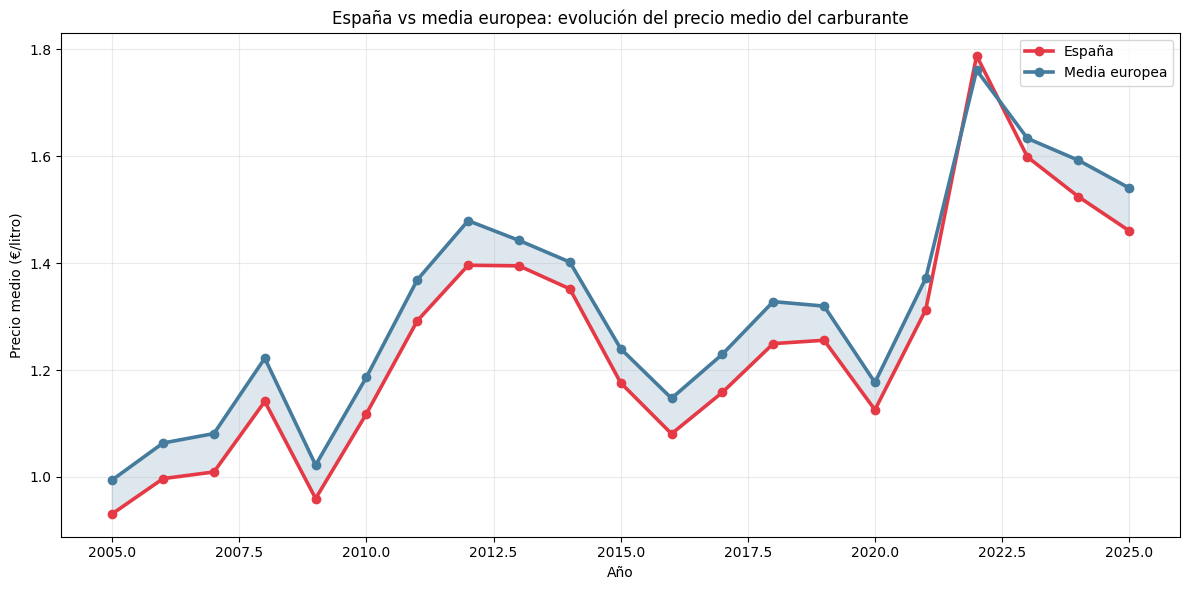

Interpretación:
España queda por debajo de la media europea en 0.080 €/l en 2025.
La subida alrededor de 2022 puede interpretarse como efecto del shock energético europeo, aunque también influyen impuestos, petróleo, logística y competencia.


In [15]:
serie = base_anual.groupby(["anio", "country_name"], as_index=False).agg({"precio_medio": "mean"})
esp = serie[serie["country_name"] == "Spain"][["anio", "precio_medio"]].rename(columns={"precio_medio": "precio_espana"})
eu = serie.groupby("anio", as_index=False).agg({"precio_medio": "mean"}).rename(columns={"precio_medio": "precio_media_europea"})
q1 = esp.merge(eu, on="anio", how="inner")
q1["diferencia_espana_europa"] = q1["precio_espana"] - q1["precio_media_europea"]
guardar_tabla(q1, "q1_espana_vs_media_europea.csv")

ultimo = q1.sort_values("anio").iloc[-1]
max_diff = q1.loc[q1["diferencia_espana_europa"].abs().idxmax()]
print(f"Último año: {int(ultimo['anio'])}")
print(f"España: {ultimo['precio_espana']:.3f} €/l | Media europea: {ultimo['precio_media_europea']:.3f} €/l")
print(f"Diferencia España-Europa: {ultimo['diferencia_espana_europa']:.3f} €/l")
print(f"Mayor diferencia absoluta: {max_diff['diferencia_espana_europa']:.3f} €/l en {int(max_diff['anio'])}")

plt.figure(figsize=(12, 6))
plt.plot(q1["anio"], q1["precio_espana"], marker="o", linewidth=2.6, color=COL_SP, label="España")
plt.plot(q1["anio"], q1["precio_media_europea"], marker="o", linewidth=2.6, color=COL_EU, label="Media europea")
plt.fill_between(q1["anio"], q1["precio_espana"], q1["precio_media_europea"],
                 where=q1["precio_espana"] >= q1["precio_media_europea"], color=COL_SP, alpha=0.18)
plt.fill_between(q1["anio"], q1["precio_espana"], q1["precio_media_europea"],
                 where=q1["precio_espana"] < q1["precio_media_europea"], color=COL_EU, alpha=0.18)
plt.title("España vs media europea: evolución del precio medio del carburante")
plt.xlabel("Año")
plt.ylabel("Precio medio (€/litro)")
plt.legend()
plt.tight_layout()
guardar_grafico("q1_espana_vs_media_europea.png")
plt.show()

print("Interpretación:")
if ultimo["diferencia_espana_europa"] < 0:
    print(f"España queda por debajo de la media europea en {abs(ultimo['diferencia_espana_europa']):.3f} €/l en {int(ultimo['anio'])}.")
else:
    print(f"España queda por encima de la media europea en {ultimo['diferencia_espana_europa']:.3f} €/l en {int(ultimo['anio'])}.")
print("La subida alrededor de 2022 puede interpretarse como efecto del shock energético europeo, aunque también influyen impuestos, petróleo, logística y competencia.")

### Interpretación de resultados

En el último año disponible, España aparece por debajo de la media europea. El propio código imprime una diferencia de aproximadamente **-0,080 €/litro en 2025**, lo que indica que el precio medio español es inferior al promedio europeo. La mayor diferencia absoluta se observa alrededor de 2012, con una separación cercana a **-0,083 €/litro**.

La lectura analítica es que España no se encuentra entre los mercados más caros de Europa. Una posible causa es que los países del norte y centro de Europa suelen presentar mayores costes, mayor renta disponible y estructuras fiscales diferentes. Aun así, España sigue la misma tendencia general: cuando Europa sube, España también sube. Esto sugiere que existe un componente común europeo vinculado al precio internacional del petróleo, la inflación energética, la fiscalidad y los shocks de oferta.


## Pregunta 2 — Top 10 de gasolina más cara en Europa + España

**Pregunta reflexiva:** ¿Dónde se sitúa España frente a los países europeos con la gasolina más cara?

**Hipótesis:** España no debería entrar en el top 10 de países más caros, pero conviene añadirla al gráfico para no perder la referencia nacional del proyecto.

**Idea del gráfico:** se muestran los 10 países con gasolina más cara en 2025 y se añade España como referencia aunque no pertenezca al top 10. La línea de media europea permite saber si España está por encima o por debajo del conjunto.

**Operación relacionada:** ranking top-N y comparación con una categoría de referencia.


Tabla guardada en: outputs/tablas/q2_ranking_gasolina_2025.csv
España ocupa el puesto 15 con 1.495 €/l
Media europea gasolina 2025: 1.562 €/l
Gráfico guardado en: outputs/graficos/q2_top10_gasolina_mas_espana_2025.png


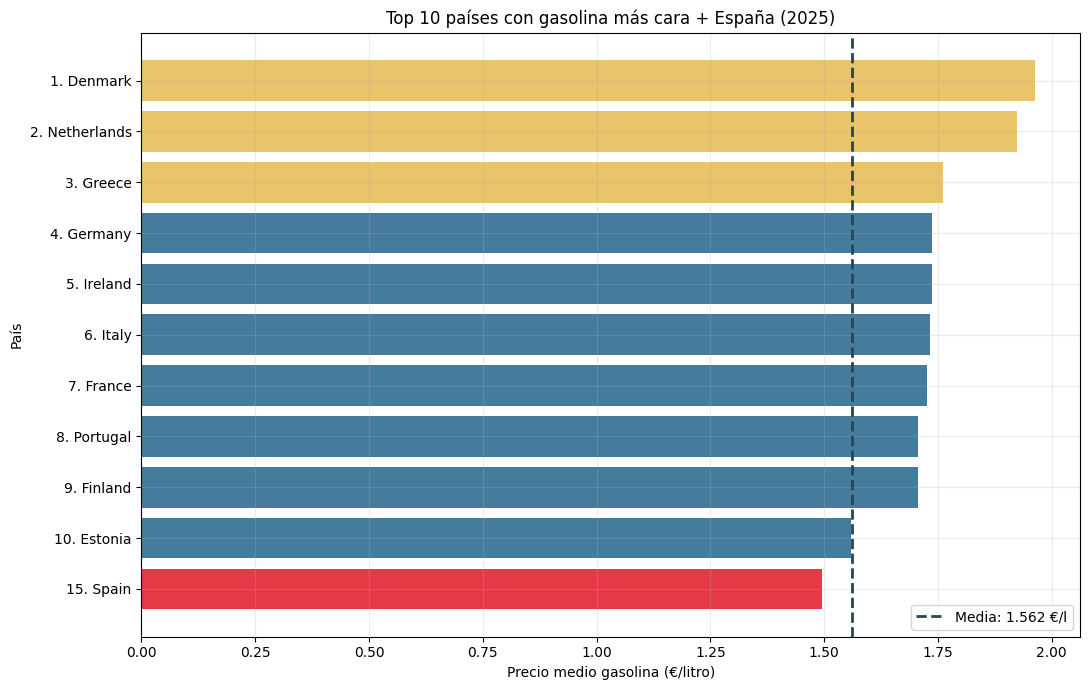

Interpretación:
España está -0.067 €/l respecto a la media. Se añade aunque no esté en el top 10 para contextualizar su posición real.


In [16]:
anio_top = 2025 if 2025 in base_anual["anio"].unique() else ultimo_anio
q2_base = base_anual[(base_anual["anio"] == anio_top) & (base_anual["nombre_es"] == "Gasolina")] \
    .groupby("country_name", as_index=False).agg({"precio_medio": "mean"}) \
    .sort_values("precio_medio", ascending=False).reset_index(drop=True)
q2_base["ranking"] = q2_base.index + 1
media_q2 = q2_base["precio_medio"].mean()
top10 = q2_base.head(10).copy()
espana_row = q2_base[q2_base["country_name"] == "Spain"].copy()
q2_plot = pd.concat([top10, espana_row], ignore_index=True) if (not espana_row.empty and "Spain" not in top10["country_name"].values) else top10.copy()
q2_plot["label"] = q2_plot.apply(lambda r: f'{int(r["ranking"])}. {r["country_name"]}', axis=1)
guardar_tabla(q2_base, f"q2_ranking_gasolina_{anio_top}.csv")

if not espana_row.empty:
    print(f"España ocupa el puesto {int(espana_row['ranking'].iloc[0])} con {espana_row['precio_medio'].iloc[0]:.3f} €/l")
print(f"Media europea gasolina {anio_top}: {media_q2:.3f} €/l")

q2_plot_ord = q2_plot.sort_values("precio_medio", ascending=True)
colors = []
for _, r in q2_plot_ord.iterrows():
    if r["country_name"] == "Spain": colors.append(COL_SP)
    elif int(r["ranking"]) <= 3: colors.append(COL_GOLD)
    else: colors.append(COL_EU)

plt.figure(figsize=(11, 7))
plt.barh(q2_plot_ord["label"], q2_plot_ord["precio_medio"], color=colors)
plt.axvline(media_q2, color=COL_DARK, linestyle="--", linewidth=2, label=f"Media: {media_q2:.3f} €/l")
plt.title(f"Top 10 países con gasolina más cara + España ({anio_top})")
plt.xlabel("Precio medio gasolina (€/litro)")
plt.ylabel("País")
plt.legend()
plt.tight_layout()
guardar_grafico(f"q2_top10_gasolina_mas_espana_{anio_top}.png")
plt.show()

print("Interpretación:")
if not espana_row.empty:
    dif = espana_row["precio_medio"].iloc[0] - media_q2
    print(f"España está {dif:.3f} €/l respecto a la media. Se añade aunque no esté en el top 10 para contextualizar su posición real.")

### Interpretación de resultados

El ranking muestra que España queda fuera del top 10 de gasolina más cara. El código indica que ocupa aproximadamente el **puesto 15** y que su precio medio de gasolina en 2025 es de **1,495 €/litro**, frente a una media europea de **1,562 €/litro**. Por tanto, España queda unos **0,067 €/litro por debajo de la media**.

Esto refuerza la conclusión de que España no es un mercado especialmente caro en términos relativos. Los países del top 10 pueden estar influidos por mayores impuestos, mayores costes de distribución, menor competencia o estructuras de mercado diferentes. Añadir España al final de la gráfica es importante porque evita una lectura incompleta: aunque no esté entre los más caros, se ve claramente su posición frente al grupo líder.


## Pregunta 3 — Brecha gasolina-gasóleo en España

**Pregunta reflexiva:** ¿La gasolina y el gasóleo evolucionan igual en España o existe una brecha relevante entre ambos?

**Hipótesis:** ambos combustibles deberían moverse de forma parecida porque comparten factores comunes, como petróleo, refino, logística e inflación energética. Sin embargo, la brecha no tiene por qué ser constante por diferencias de demanda, fiscalidad y mercado de refinados.

**Idea del gráfico:** se representan gasolina y gasóleo en España con una zona sombreada que mide la distancia entre ambos. El gráfico destaca el año con mayor separación.

**Operación relacionada:** slice de España + comparación por dimensión producto.


Tabla guardada en: outputs/tablas/q3_brecha_gasolina_gasoleo_espana.csv
Mayor brecha absoluta: 0.138 €/l en 2016
Gráfico guardado en: outputs/graficos/q3_brecha_gasolina_gasoleo_espana.png


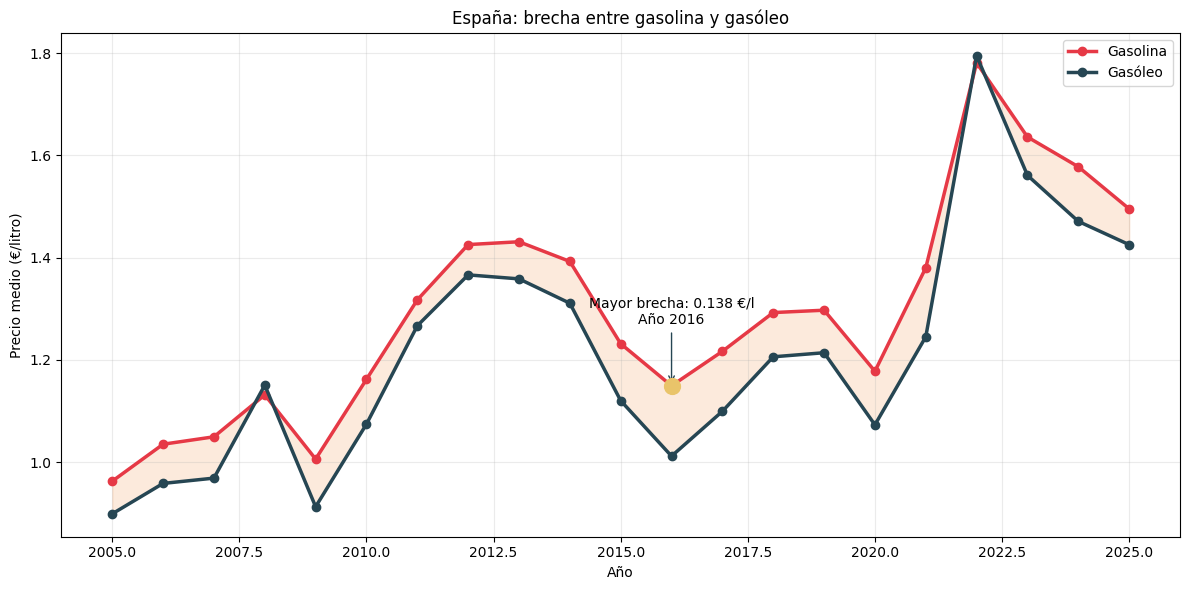

Interpretación: la zona sombreada representa la distancia entre ambos combustibles. La brecha no es estable y puede cambiar por demanda, fiscalidad y mercado de refinados.


In [17]:
q3 = base_anual[(base_anual["country_name"] == "Spain") & (base_anual["nombre_es"].isin(["Gasolina", "Gasóleo"]))] \
    .pivot_table(index="anio", columns="nombre_es", values="precio_medio", aggfunc="mean").reset_index()
q3 = q3.dropna(subset=["Gasolina", "Gasóleo"]).sort_values("anio")
q3["brecha"] = q3["Gasolina"] - q3["Gasóleo"]
guardar_tabla(q3, "q3_brecha_gasolina_gasoleo_espana.csv")
fila_max = q3.loc[q3["brecha"].abs().idxmax()]
anio_max = int(fila_max["anio"]); brecha_max = fila_max["brecha"]
print(f"Mayor brecha absoluta: {brecha_max:.3f} €/l en {anio_max}")

plt.figure(figsize=(12, 6))
plt.plot(q3["anio"], q3["Gasolina"], marker="o", color=COL_SP, linewidth=2.5, label="Gasolina")
plt.plot(q3["anio"], q3["Gasóleo"], marker="o", color=COL_DARK, linewidth=2.5, label="Gasóleo")
plt.fill_between(q3["anio"], q3["Gasolina"], q3["Gasóleo"], color=COL_ACCENT, alpha=0.22)
plt.scatter(anio_max, fila_max["Gasolina"], s=130, color=COL_GOLD, zorder=5)
plt.annotate(f"Mayor brecha: {brecha_max:.3f} €/l\nAño {anio_max}", xy=(anio_max, fila_max["Gasolina"]),
             xytext=(anio_max, fila_max["Gasolina"] + 0.12), arrowprops=dict(arrowstyle="->", color=COL_DARK), ha="center")
plt.title("España: brecha entre gasolina y gasóleo")
plt.xlabel("Año")
plt.ylabel("Precio medio (€/litro)")
plt.legend()
plt.tight_layout()
guardar_grafico("q3_brecha_gasolina_gasoleo_espana.png")
plt.show()
print("Interpretación: la zona sombreada representa la distancia entre ambos combustibles. La brecha no es estable y puede cambiar por demanda, fiscalidad y mercado de refinados.")

### Interpretación de resultados

La gráfica muestra que gasolina y gasóleo se mueven de forma bastante sincronizada, pero la brecha entre ambos cambia con el tiempo. El código detecta una brecha máxima cercana a **0,138 €/litro en 2016**.

La interpretación es que ambos productos comparten una base común de costes, pero no son idénticos. La gasolina suele situarse por encima del gasóleo en varios años, aunque la diferencia depende de demanda, fiscalidad, márgenes, disponibilidad de refinados y condiciones internacionales. En 2022 se aprecia un salto claro en ambos combustibles, coherente con un shock energético general y no solo con una diferencia puntual entre productos.


## Pregunta 4 — Heatmap de precio de gasolina por país y año

**Pregunta reflexiva:** ¿Qué países mantienen precios de gasolina altos de forma persistente y qué años concentran mayores tensiones?

**Hipótesis:** los países más caros deberían aparecer con tonos intensos de forma recurrente, mientras que 2022 debería destacar en la mayoría de países por el shock energético.

**Idea del gráfico:** el heatmap cruza países y años para gasolina. Los colores más intensos indican precios más altos. Esta visualización permite detectar patrones persistentes y años anómalos de un vistazo.

**Operación relacionada:** pivot visual país-año para un producto concreto.


Tabla guardada en: outputs/tablas/q4_heatmap_gasolina_2024.csv
Gráfico guardado en: outputs/graficos/q4_heatmap_gasolina_2015_2024.png


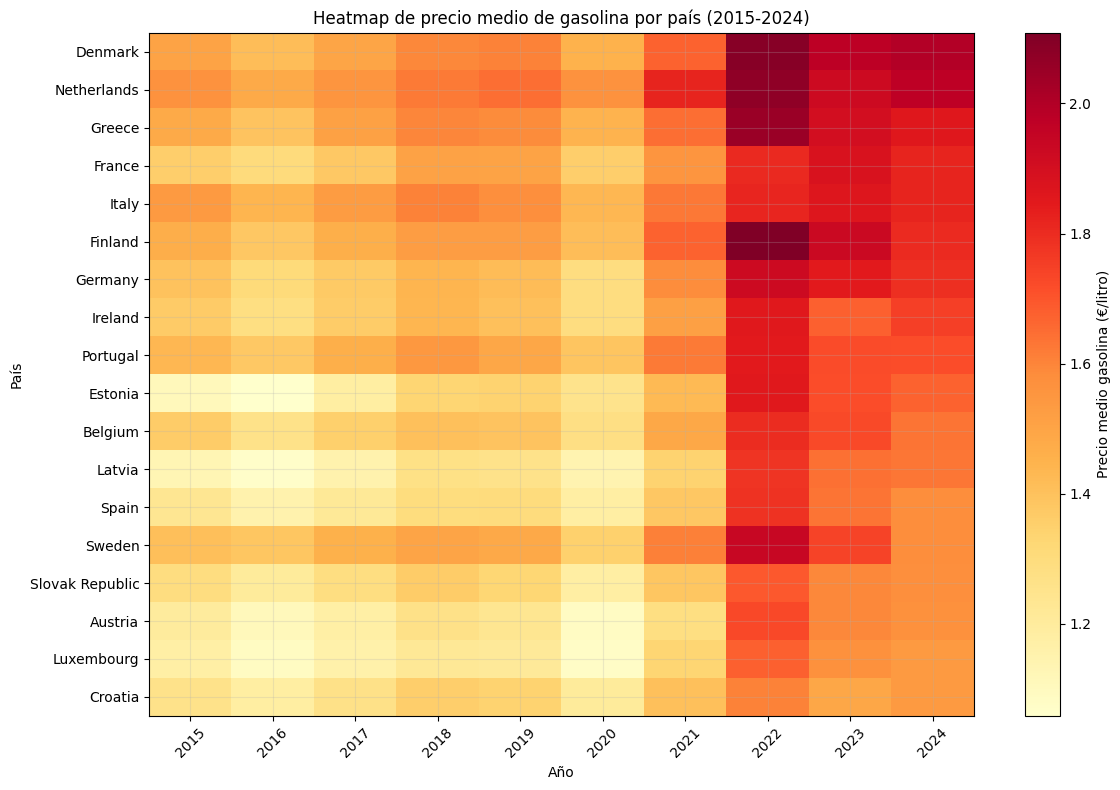

Interpretación: tonos más intensos indican gasolina más cara. Permite detectar países caros de forma persistente y años de shock como 2022.


In [18]:
anio_heat = 2024 if 2024 in base_anual["anio"].unique() else ultimo_anio
anios_heat = list(range(anio_heat - 9, anio_heat + 1))
gas_heat = base_anual[(base_anual["nombre_es"] == "Gasolina") & (base_anual["anio"].isin(anios_heat))].copy()
top_paises_heat = gas_heat[gas_heat["anio"] == anio_heat].sort_values("precio_medio", ascending=False).head(18)["country_name"].tolist()
heat = gas_heat[gas_heat["country_name"].isin(top_paises_heat)].pivot_table(index="country_name", columns="anio", values="precio_medio", aggfunc="mean")
heat = heat.sort_values(anio_heat, ascending=False)
guardar_tabla(heat.reset_index(), f"q4_heatmap_gasolina_{anio_heat}.csv")

plt.figure(figsize=(12, 8))
im = plt.imshow(heat, aspect="auto", cmap="YlOrRd")
plt.colorbar(im, label="Precio medio gasolina (€/litro)")
plt.xticks(range(len(heat.columns)), heat.columns, rotation=45)
plt.yticks(range(len(heat.index)), heat.index)
plt.title(f"Heatmap de precio medio de gasolina por país ({anios_heat[0]}-{anio_heat})")
plt.xlabel("Año")
plt.ylabel("País")
plt.tight_layout()
guardar_grafico(f"q4_heatmap_gasolina_{anios_heat[0]}_{anio_heat}.png")
plt.show()
print("Interpretación: tonos más intensos indican gasolina más cara. Permite detectar países caros de forma persistente y años de shock como 2022.")

### Interpretación de resultados

El heatmap permite identificar dos tipos de señales: países estructuralmente caros y años especialmente tensos. Si un país mantiene colores intensos durante muchos años, el precio alto parece estructural. Si casi todos los países se oscurecen en un mismo año, la causa parece común y externa.

La lectura más relevante es la concentración de precios altos alrededor de 2022 y años posteriores. Esto puede relacionarse con la crisis energética europea, el encarecimiento de materias primas energéticas y la incertidumbre geopolítica. También se observan diferencias nacionales que pueden explicarse por fiscalidad, localización, costes de transporte, dependencia energética y estructura competitiva del mercado de carburantes.


## Pregunta 5 — Mapa europeo del precio de gasolina

**Pregunta reflexiva:** ¿Existe un patrón geográfico claro en los precios de la gasolina en Europa?

**Hipótesis:** los precios no se distribuyen al azar; deberían observarse diferencias territoriales relacionadas con fiscalidad, renta, logística, dependencia energética y estructura de mercado.

**Idea del gráfico:** el mapa muestra el precio medio de la gasolina por país. Es una visualización territorial que permite leer el dato de forma más intuitiva que una tabla.

**Operación relacionada:** agregación geográfica y visualización espacial.


In [19]:
anio_mapa = 2024 if 2024 in base_anual["anio"].unique() else ultimo_anio
map_last = base_anual[(base_anual["anio"] == anio_mapa) & (base_anual["nombre_es"] == "Gasolina")].groupby("country_name", as_index=False).agg({"precio_medio": "mean", "impuesto_medio": "mean"})
guardar_tabla(map_last, f"q5_mapa_gasolina_europa_{anio_mapa}.csv")
fig = px.choropleth(map_last, locations="country_name", locationmode="country names", color="precio_medio", hover_name="country_name", hover_data={"precio_medio": ":.3f", "impuesto_medio": ":.3f"}, color_continuous_scale="Blues", title=f"Mapa europeo del precio medio de gasolina ({anio_mapa})")
fig.update_geos(scope="europe", projection_type="mercator", showland=True, landcolor="rgb(245,245,245)", showcountries=True, countrycolor="rgb(180,180,180)", showcoastlines=True, coastlinecolor="rgb(120,120,120)", showocean=True, oceancolor="rgb(230,240,250)", lonaxis_range=[-25,45], lataxis_range=[34,72])
fig.update_layout(width=950, height=650, margin=dict(l=20,r=20,t=70,b=20), coloraxis_colorbar=dict(title="€/litro"))
fig.show()
fig.write_html(f"outputs/graficos/q5_mapa_gasolina_europa_{anio_mapa}.html")
print(f"Mapa interactivo guardado en outputs/graficos/q5_mapa_gasolina_europa_{anio_mapa}.html")
print("Interpretación: el mapa muestra patrones territoriales; diferencias nacionales pueden deberse a impuestos, logística, dependencia y estructura de mercado.")

Tabla guardada en: outputs/tablas/q5_mapa_gasolina_europa_2024.csv


Mapa interactivo guardado en outputs/graficos/q5_mapa_gasolina_europa_2024.html
Interpretación: el mapa muestra patrones territoriales; diferencias nacionales pueden deberse a impuestos, logística, dependencia y estructura de mercado.


### Interpretación de resultados

El mapa ayuda a detectar diferencias territoriales. Los países con colores más intensos concentran precios más altos, mientras que otros mercados aparecen relativamente más baratos. Esta lectura es útil porque el carburante es un producto internacional, pero el precio final se forma nacionalmente.

Las posibles causas incluyen impuestos indirectos, costes logísticos, competencia entre estaciones, estructura de refino e importación, poder adquisitivo y medidas públicas aplicadas tras el shock energético. En este contexto, el mapa no solo enseña “quién es más caro”, sino que ayuda a formular nuevas preguntas sobre por qué algunos países tienen precios persistentemente superiores.


## Preparación macroeconómica — PIB real del Banco Mundial

Esta celda prepara el PIB per cápita real para incorporarlo al análisis. Se utiliza una fuente externa porque el PIB integrado en el cubo podía generar valores repetidos o poco útiles para regresión.

**Idea analítica:** si se quiere estudiar si renta y precio están relacionados, el PIB debe tener variación real entre países. Por eso se carga y se cruza el PIB por código ISO3.


In [20]:
mapa_iso3 = {"Austria":"AUT","Belgium":"BEL","Bulgaria":"BGR","Croatia":"HRV","Cyprus":"CYP","Czechia":"CZE","Czech Republic":"CZE","Denmark":"DNK","Estonia":"EST","Finland":"FIN","France":"FRA","Germany":"DEU","Greece":"GRC","Hungary":"HUN","Ireland":"IRL","Italy":"ITA","Latvia":"LVA","Lithuania":"LTU","Luxembourg":"LUX","Malta":"MLT","Netherlands":"NLD","Poland":"POL","Portugal":"PRT","Romania":"ROU","Slovak Republic":"SVK","Slovakia":"SVK","Slovenia":"SVN","Spain":"ESP","Sweden":"SWE"}

def cargar_pib_worldbank():
    url = "https://api.worldbank.org/v2/country/all/indicator/NY.GDP.PCAP.CD?downloadformat=csv"
    response = requests.get(url)
    response.raise_for_status()
    z = zipfile.ZipFile(io.BytesIO(response.content))
    csv_pib = [n for n in z.namelist() if n.startswith("API_NY.GDP.PCAP.CD") and n.endswith(".csv")][0]
    raw = pd.read_csv(z.open(csv_pib), skiprows=4)
    years = [c for c in raw.columns if c.isdigit()]
    long = raw.melt(id_vars=["Country Name", "Country Code"], value_vars=years, var_name="anio", value_name="pib_per_capita_wb")
    long["anio"] = pd.to_numeric(long["anio"], errors="coerce")
    long["pib_per_capita_wb"] = pd.to_numeric(long["pib_per_capita_wb"], errors="coerce")
    long = long.dropna(subset=["Country Code", "anio", "pib_per_capita_wb"]).copy()
    long["anio"] = long["anio"].astype(int)
    return long.rename(columns={"Country Code":"iso3", "Country Name":"country_name_wb"})[["iso3", "country_name_wb", "anio", "pib_per_capita_wb"]]

pib_wb = cargar_pib_worldbank()
print("PIB World Bank cargado:", pib_wb.shape)
pib_wb.tail()

PIB World Bank cargado: (14561, 4)


,iso3,country_name_wb,anio,pib_per_capita_wb
17284,WSM,Samoa,2024,5392.877619
17285,XKX,Kosovo,2024,7023.065985
17287,ZAF,South Africa,2024,6267.186814
17288,ZMB,Zambia,2024,1187.109434
17289,ZWE,Zimbabwe,2024,2497.203322


**Validación:** la tabla de PIB cargada permite contrastar el precio de carburantes con una variable macroeconómica externa. Esto mejora la calidad del análisis porque evita basarse en una columna que pueda estar mal agregada o repetida.


## Pregunta 6 — PIB per cápita vs precio de gasolina en los últimos 10 años

**Pregunta reflexiva:** ¿Los países con mayor PIB per cápita tienden a tener gasolina más cara?

**Hipótesis:** puede existir una relación positiva, porque países con mayor renta suelen tener mayor capacidad fiscal, mayores costes y mercados con precios finales más elevados. Sin embargo, el PIB por sí solo no debería explicar todo el precio.

**Idea del gráfico:** cada punto representa un país-año. Se cruza PIB per cápita con precio de gasolina y se ajusta una regresión lineal. La correlación mide la asociación y el R² indica cuánto explica el modelo simple.

**Operación relacionada:** análisis macroeconómico con regresión.


Tabla guardada en: outputs/tablas/q6_pib_precio_gasolina_ultimos_10_anios.csv
Observaciones: 243 | Correlación: 0.323 | R²: 0.104
Gráfico guardado en: outputs/graficos/q6_regresion_pib_precio_gasolina_ultimos_10_anios.png


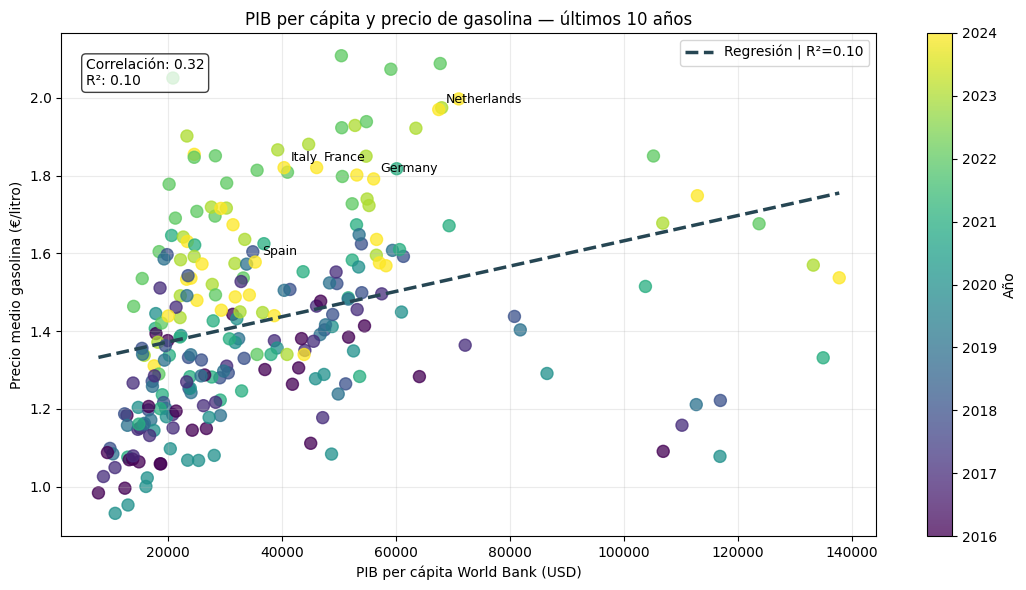

Interpretación: si la correlación es positiva, países-año con más PIB tienden a tener precios más altos; si el R² es bajo, el PIB no basta para explicar el precio.


In [21]:
gas_10 = base_anual[(base_anual["nombre_es"] == "Gasolina") & (base_anual["anio"].isin(ultimos_10))].groupby(["country_name", "anio"], as_index=False).agg({"precio_medio":"mean", "impuesto_medio":"mean", "dependencia_energetica_media":"mean"})
gas_10["iso3"] = gas_10["country_name"].map(mapa_iso3)
gas_10 = gas_10.dropna(subset=["iso3"])
q6 = gas_10.merge(pib_wb, on=["iso3","anio"], how="inner").dropna(subset=["precio_medio", "pib_per_capita_wb"])
guardar_tabla(q6, "q6_pib_precio_gasolina_ultimos_10_anios.csv")
X = q6[["pib_per_capita_wb"]].values; y = q6["precio_medio"].values
modelo_q6 = LinearRegression().fit(X,y); pred_q6 = modelo_q6.predict(X)
corr_q6 = q6["pib_per_capita_wb"].corr(q6["precio_medio"]); r2_q6 = r2_score(y,pred_q6)
print(f"Observaciones: {len(q6)} | Correlación: {corr_q6:.3f} | R²: {r2_q6:.3f}")
plt.figure(figsize=(11,6))
sc = plt.scatter(q6["pib_per_capita_wb"], q6["precio_medio"], c=q6["anio"], cmap="viridis", s=75, alpha=0.75)
xline = np.linspace(q6["pib_per_capita_wb"].min(), q6["pib_per_capita_wb"].max(), 200)
plt.plot(xline, modelo_q6.predict(xline.reshape(-1,1)), linestyle="--", linewidth=2.5, color=COL_DARK, label=f"Regresión | R²={r2_q6:.2f}")
for _, row in q6.iterrows():
    if row["country_name"] in ["Spain","Germany","France","Italy","Netherlands"] and row["anio"] == q6["anio"].max():
        plt.annotate(row["country_name"], (row["pib_per_capita_wb"], row["precio_medio"]), fontsize=9, xytext=(5,5), textcoords="offset points")
plt.colorbar(sc, label="Año")
plt.text(0.03,0.95,f"Correlación: {corr_q6:.2f}\nR²: {r2_q6:.2f}", transform=plt.gca().transAxes, va="top", bbox=dict(boxstyle="round", facecolor="white", alpha=0.75))
plt.title("PIB per cápita y precio de gasolina — últimos 10 años")
plt.xlabel("PIB per cápita World Bank (USD)")
plt.ylabel("Precio medio gasolina (€/litro)")
plt.legend(); plt.tight_layout(); guardar_grafico("q6_regresion_pib_precio_gasolina_ultimos_10_anios.png"); plt.show()
print("Interpretación: si la correlación es positiva, países-año con más PIB tienden a tener precios más altos; si el R² es bajo, el PIB no basta para explicar el precio.")

### Interpretación de resultados

El código obtiene **243 observaciones**, una **correlación positiva aproximada de 0,323** y un **R² de 0,104**. Esto significa que existe cierta asociación positiva entre PIB per cápita y precio de gasolina, pero el poder explicativo es limitado: el PIB explica solo una parte pequeña de la variación.

Desde una visión de analista, el resultado es razonable. Los países más ricos pueden tener precios finales más altos por mayores impuestos, costes y estructura de mercado, pero el precio de la gasolina también depende de petróleo, tipo de cambio, fiscalidad, logística, competencia, refino y shocks externos. Por eso el PIB sirve como variable de contexto, no como explicación completa.


## Pregunta 7A — Composición orientativa del precio de gasolina en España

**Pregunta reflexiva:** ¿Qué parte del precio de la gasolina corresponde a impuestos y qué parte queda antes de impuestos?

**Hipótesis:** la fiscalidad debería representar una parte relevante del precio final de la gasolina. Por eso no era correcto interpretar como fiscalidad total los valores muy bajos de `impuesto_eur_litro` del cubo.

**Idea del gráfico:** se muestra un donut con el precio antes de impuestos y el desglose fiscal: IVA, Impuesto Especial de Hidrocarburos tipo general y tipo especial.

**Nota metodológica:** este gráfico es contextual. El precio final se obtiene del cubo y el desglose fiscal se construye con tipos fiscales conocidos para España.


Año usado: 2025
Precio medio gasolina España: 1.495 €/litro
Tabla guardada en: outputs/tablas/q7_desglose_precio_gasolina_espana_2025.csv


,bloque,valor_eur_litro,porcentaje_precio_final
0,Precio antes de impuestos,0.763254,51.036974
1,IVA,0.259548,17.355372
2,Impuesto especial hidrocarburos - tipo general,0.400690,26.793185
3,Impuesto especial hidrocarburos - tipo especial,0.072000,4.814468


Comprobación suma componentes: 1.4954922028846154
Precio final usado: 1.4954922028846152
Gráfico guardado en: outputs/graficos/q7_donut_desglose_precio_gasolina_espana_2025.png


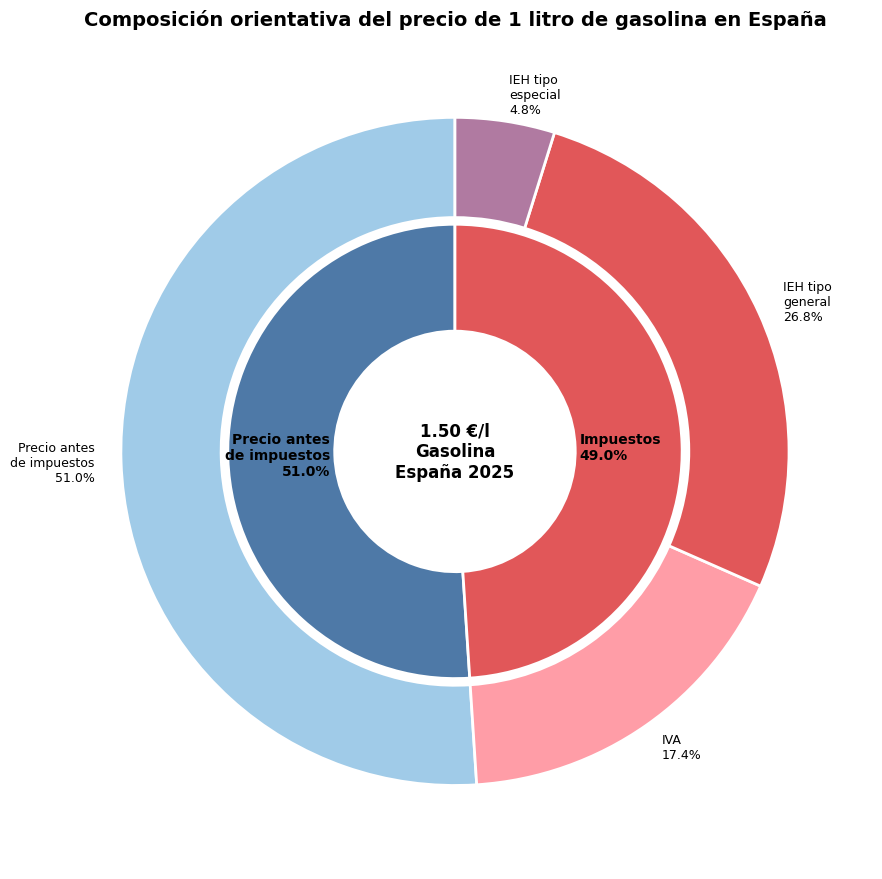

In [22]:
# GRÁFICO EXTRA — Composición orientativa del precio de 1 litro de gasolina en España
# Donut doble: precio antes de impuestos + impuestos desglosados

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

os.makedirs("outputs/graficos", exist_ok=True)
os.makedirs("outputs/tablas", exist_ok=True)

# Por si no existen las funciones de guardado
try:
    guardar_tabla
except NameError:
    def guardar_tabla(df, nombre):
        ruta = "outputs/tablas/" + nombre
        df.to_csv(ruta, index=False)
        print("Tabla guardada en:", ruta)

try:
    guardar_grafico
except NameError:
    def guardar_grafico(nombre):
        ruta = "outputs/graficos/" + nombre
        plt.savefig(ruta, dpi=150, bbox_inches="tight")
        print("Gráfico guardado en:", ruta)

# ------------------------------------------------------------
# 1. Sacamos el precio medio de gasolina en España del último año disponible
# ------------------------------------------------------------

precio_base_pie = fact_pd.merge(
    dim_tiempo_pd[["sk_tiempo", "anio"]],
    on="sk_tiempo",
    how="left"
).merge(
    dim_geo_pd[["sk_geografia", "country_name"]],
    on="sk_geografia",
    how="left"
).merge(
    dim_producto_pd[["sk_producto", "nombre_es"]],
    on="sk_producto",
    how="left"
)

precio_base_pie["anio"] = pd.to_numeric(precio_base_pie["anio"], errors="coerce")
precio_base_pie["precio_eur_litro"] = pd.to_numeric(
    precio_base_pie["precio_eur_litro"],
    errors="coerce"
)

precio_base_pie = precio_base_pie.dropna(subset=[
    "anio",
    "country_name",
    "nombre_es",
    "precio_eur_litro"
]).copy()

precio_base_pie["anio"] = precio_base_pie["anio"].astype(int)

# Filtramos España + gasolina
precio_espana_gasolina = precio_base_pie[
    (precio_base_pie["country_name"].isin(["Spain", "España"])) &
    (precio_base_pie["nombre_es"] == "Gasolina") &
    (precio_base_pie["precio_eur_litro"] > 0)
].copy()

# Último año disponible para España
anio_pie = int(precio_espana_gasolina["anio"].max())

precio_espana_gasolina = precio_espana_gasolina[
    precio_espana_gasolina["anio"] == anio_pie
].copy()

precio_final = precio_espana_gasolina["precio_eur_litro"].mean()

print(f"Año usado: {anio_pie}")
print(f"Precio medio gasolina España: {precio_final:.3f} €/litro")

# ------------------------------------------------------------
# 2. Parámetros fiscales oficiales/orientativos para gasolina 95 en España
# ------------------------------------------------------------

iva_pct = 0.21

# Impuesto Especial de Hidrocarburos para gasolina 95
ieh_tipo_general = 0.40069   # €/litro
ieh_tipo_especial = 0.07200  # €/litro

# El IVA incluido en el precio final se obtiene como PVP * 21 / 121
iva_eur_litro = precio_final * iva_pct / (1 + iva_pct)

impuestos_total = iva_eur_litro + ieh_tipo_general + ieh_tipo_especial

precio_antes_impuestos = precio_final - impuestos_total

if precio_antes_impuestos < 0:
    raise ValueError(
        "El precio antes de impuestos sale negativo. Revisa el precio final o los tipos fiscales usados."
    )

# ------------------------------------------------------------
# 3. Tabla de composición
# ------------------------------------------------------------

componentes = pd.DataFrame({
    "bloque": [
        "Precio antes de impuestos",
        "IVA",
        "Impuesto especial hidrocarburos - tipo general",
        "Impuesto especial hidrocarburos - tipo especial"
    ],
    "valor_eur_litro": [
        precio_antes_impuestos,
        iva_eur_litro,
        ieh_tipo_general,
        ieh_tipo_especial
    ]
})

componentes["porcentaje_precio_final"] = (
    componentes["valor_eur_litro"] / precio_final
) * 100

guardar_tabla(
    componentes,
    f"q7_desglose_precio_gasolina_espana_{anio_pie}.csv"
)

display(componentes)

print("Comprobación suma componentes:", componentes["valor_eur_litro"].sum())
print("Precio final usado:", precio_final)

# ------------------------------------------------------------
# 4. Donut doble
# ------------------------------------------------------------

# Anillo interior: impuestos vs precio antes de impuestos
inner_labels = [
    "Precio antes\nde impuestos",
    "Impuestos"
]

inner_values = [
    precio_antes_impuestos,
    impuestos_total
]

# Anillo exterior: desglose de impuestos
outer_labels = [
    "Precio antes\nde impuestos",
    "IVA",
    "IEH tipo\ngeneral",
    "IEH tipo\nespecial"
]

outer_values = [
    precio_antes_impuestos,
    iva_eur_litro,
    ieh_tipo_general,
    ieh_tipo_especial
]

# Colores
inner_colors = [
    "#4E79A7",  # precio antes impuestos
    "#E15759"   # impuestos
]

outer_colors = [
    "#A0CBE8",  # precio antes impuestos
    "#FF9DA7",  # IVA
    "#E15759",  # IEH general
    "#B07AA1"   # IEH especial
]

plt.figure(figsize=(9, 9))

# Anillo exterior
plt.pie(
    outer_values,
    radius=1.0,
    labels=[
        f"{label}\n{value/precio_final*100:.1f}%"
        for label, value in zip(outer_labels, outer_values)
    ],
    colors=outer_colors,
    startangle=90,
    labeldistance=1.08,
    wedgeprops=dict(width=0.30, edgecolor="white", linewidth=2),
    textprops={"fontsize": 9}
)

# Anillo interior
plt.pie(
    inner_values,
    radius=0.68,
    labels=[
        f"{label}\n{value/precio_final*100:.1f}%"
        for label, value in zip(inner_labels, inner_values)
    ],
    colors=inner_colors,
    startangle=90,
    labeldistance=0.55,
    wedgeprops=dict(width=0.32, edgecolor="white", linewidth=2),
    textprops={"fontsize": 10, "fontweight": "bold"}
)

# Centro
plt.text(
    0,
    0,
    f"{precio_final:.2f} €/l\nGasolina\nEspaña {anio_pie}",
    ha="center",
    va="center",
    fontsize=12,
    fontweight="bold"
)

plt.title(
    "Composición orientativa del precio de 1 litro de gasolina en España",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()

guardar_grafico(f"q7_donut_desglose_precio_gasolina_espana_{anio_pie}.png")
plt.show()

### Interpretación de resultados

El gráfico muestra que, para España en 2025, el precio medio usado es aproximadamente **1,495 €/litro**. La composición estimada queda repartida en torno a **51,0% precio antes de impuestos**, **17,4% IVA**, **26,8% Impuesto Especial tipo general** y **4,8% tipo especial**.

Esta visualización corrige el problema detectado en los primeros gráficos de impuestos: valores de 0,01 o 0,02 €/litro no podían representar la carga fiscal total de la gasolina. La interpretación económica es clara: el precio final no depende solo del producto energético, sino también de una fiscalidad fija por litro y de un IVA ligado al precio final.


## Pregunta 7B — Barra apilada de componentes del precio

**Pregunta reflexiva:** ¿Cómo se reparte visualmente cada euro pagado por litro de gasolina en España?

**Hipótesis:** una barra apilada debería comunicar mejor que un scatter la composición del precio, porque separa claramente producto antes de impuestos e impuestos.

**Idea del gráfico:** se representa un litro de gasolina como una barra horizontal compuesta por precio antes de impuestos, IVA, IEH tipo general e IEH tipo especial.


Año usado: 2025
Precio medio gasolina España: 1.495 €/litro
Tabla guardada en: outputs/tablas/grafico_impuestos_composicion_gasolina_espana_2025.csv


,componente,valor_eur_litro,porcentaje
0,Precio antes de impuestos,0.763254,51.036974
1,IVA,0.259548,17.355372
2,IEH tipo general,0.400690,26.793185
3,IEH tipo especial,0.072000,4.814468


Suma componentes: 1.4954922028846154
Precio final: 1.4954922028846152
Gráfico guardado en: outputs/graficos/grafico_impuestos_barra_apilada_gasolina_espana_2025.png


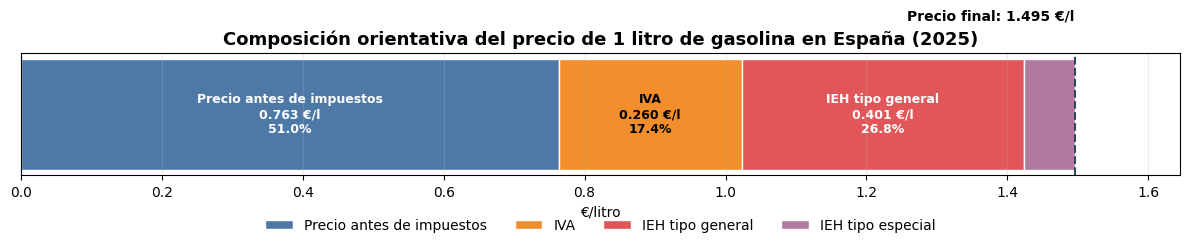

In [23]:
# PREGUNTA IMPUESTOS — Composición orientativa del precio de 1 litro de gasolina en España
# Barra apilada: precio antes de impuestos + IVA + IEH tipo general + IEH tipo especial

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

os.makedirs("outputs/graficos", exist_ok=True)
os.makedirs("outputs/tablas", exist_ok=True)

# Por si no existen las funciones de guardado
try:
    guardar_tabla
except NameError:
    def guardar_tabla(df, nombre):
        ruta = "outputs/tablas/" + nombre
        df.to_csv(ruta, index=False)
        print("Tabla guardada en:", ruta)

try:
    guardar_grafico
except NameError:
    def guardar_grafico(nombre):
        ruta = "outputs/graficos/" + nombre
        plt.savefig(ruta, dpi=150, bbox_inches="tight")
        print("Gráfico guardado en:", ruta)

# ------------------------------------------------------------
# 1. Precio medio de gasolina en España en el último año disponible
# ------------------------------------------------------------

precio_base_imp = fact_pd.merge(
    dim_tiempo_pd[["sk_tiempo", "anio"]],
    on="sk_tiempo",
    how="left"
).merge(
    dim_geo_pd[["sk_geografia", "country_name"]],
    on="sk_geografia",
    how="left"
).merge(
    dim_producto_pd[["sk_producto", "nombre_es"]],
    on="sk_producto",
    how="left"
)

precio_base_imp["anio"] = pd.to_numeric(precio_base_imp["anio"], errors="coerce")
precio_base_imp["precio_eur_litro"] = pd.to_numeric(
    precio_base_imp["precio_eur_litro"],
    errors="coerce"
)

precio_base_imp = precio_base_imp.dropna(subset=[
    "anio",
    "country_name",
    "nombre_es",
    "precio_eur_litro"
]).copy()

precio_base_imp["anio"] = precio_base_imp["anio"].astype(int)

esp_gas = precio_base_imp[
    (precio_base_imp["country_name"].isin(["Spain", "España"])) &
    (precio_base_imp["nombre_es"] == "Gasolina") &
    (precio_base_imp["precio_eur_litro"] > 0)
].copy()

anio_imp = int(esp_gas["anio"].max())

esp_gas = esp_gas[esp_gas["anio"] == anio_imp].copy()

precio_final = esp_gas["precio_eur_litro"].mean()

print(f"Año usado: {anio_imp}")
print(f"Precio medio gasolina España: {precio_final:.3f} €/litro")

# ------------------------------------------------------------
# 2. Parámetros fiscales orientativos para gasolina 95 en España
# ------------------------------------------------------------
# IEH = Impuesto Especial sobre Hidrocarburos.
# CNMC explica que el PAI se calcula detrayendo IVA e impuesto sobre hidrocarburos
# y distingue tipo general y tipo especial.
# Tipo general gasolina 95: 40,069 céntimos/litro
# Tipo especial: 7,2 céntimos/litro
# IVA general: 21%

iva_pct = 0.21
ieh_tipo_general = 0.40069
ieh_tipo_especial = 0.07200

# IVA incluido en precio final: PVP * 21 / 121
iva_eur = precio_final * iva_pct / (1 + iva_pct)

impuestos_total = iva_eur + ieh_tipo_general + ieh_tipo_especial

precio_antes_impuestos = precio_final - impuestos_total

if precio_antes_impuestos <= 0:
    raise ValueError("El precio antes de impuestos sale negativo. Revisa precio_final o tipos fiscales.")

componentes_imp = pd.DataFrame({
    "componente": [
        "Precio antes de impuestos",
        "IVA",
        "IEH tipo general",
        "IEH tipo especial"
    ],
    "valor_eur_litro": [
        precio_antes_impuestos,
        iva_eur,
        ieh_tipo_general,
        ieh_tipo_especial
    ]
})

componentes_imp["porcentaje"] = componentes_imp["valor_eur_litro"] / precio_final * 100

guardar_tabla(
    componentes_imp,
    f"grafico_impuestos_composicion_gasolina_espana_{anio_imp}.csv"
)

display(componentes_imp)

print("Suma componentes:", componentes_imp["valor_eur_litro"].sum())
print("Precio final:", precio_final)

# ------------------------------------------------------------
# 3. Gráfico: barra apilada horizontal
# ------------------------------------------------------------

colores = {
    "Precio antes de impuestos": "#4E79A7",
    "IVA": "#F28E2B",
    "IEH tipo general": "#E15759",
    "IEH tipo especial": "#B07AA1"
}

plt.figure(figsize=(12, 3.2))

left = 0

for _, row in componentes_imp.iterrows():
    comp = row["componente"]
    valor = row["valor_eur_litro"]
    pct = row["porcentaje"]

    plt.barh(
        ["Gasolina España"],
        valor,
        left=left,
        color=colores[comp],
        edgecolor="white",
        height=0.55,
        label=comp
    )

    # etiqueta dentro del bloque si hay espacio
    if pct > 5:
        plt.text(
            left + valor / 2,
            0,
            f"{comp}\n{valor:.3f} €/l\n{pct:.1f}%",
            ha="center",
            va="center",
            fontsize=9,
            color="white" if comp in ["IEH tipo general", "Precio antes de impuestos"] else "black",
            fontweight="bold"
        )

    left += valor

plt.axvline(precio_final, color="#2F4858", linestyle="--", linewidth=1.5)

plt.text(
    precio_final,
    0.45,
    f"Precio final: {precio_final:.3f} €/l",
    ha="right",
    va="bottom",
    fontsize=10,
    fontweight="bold"
)

plt.title(
    f"Composición orientativa del precio de 1 litro de gasolina en España ({anio_imp})",
    fontsize=13,
    fontweight="bold"
)

plt.xlabel("€/litro")
plt.xlim(0, precio_final * 1.10)
plt.yticks([])
plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.25),
    ncol=4,
    frameon=False
)

plt.tight_layout()

guardar_grafico(f"grafico_impuestos_barra_apilada_gasolina_espana_{anio_imp}.png")
plt.show()

### Interpretación de resultados

La barra apilada confirma que la fiscalidad pesa de forma importante en el precio final. El precio antes de impuestos representa algo más de la mitad del precio, mientras que el resto se reparte entre IVA e impuestos especiales.

Como analista, esta visualización es más defendible que una regresión fiscal con una variable mal construida. Permite explicar por qué dos países pueden tener precios finales diferentes aunque el coste internacional del carburante sea parecido: cada país aplica fiscalidad, recargos y estructuras de precio distintas.


## Pregunta 8A — Dependencia energética y precio de gasolina en cinco países

**Pregunta reflexiva:** ¿La dependencia energética explica el precio de la gasolina igual en España, Francia, Países Bajos, Alemania e Italia?

**Hipótesis:** la relación debería variar mucho por país. La dependencia energética es una variable estructural, mientras que el precio de gasolina se mueve también por petróleo, impuestos, refino, logística y shocks.

**Idea del gráfico:** se usa una mini-gráfica por país para evitar el caos visual de mezclar todos los puntos en un solo panel. Cada país tiene su propia regresión, correlación y R².

**Operación relacionada:** dice de cinco países + regresión por país.


Tabla guardada en: outputs/tablas/q8_dependencia_precio_gasolina_5_paises_ultimos_10_anios.csv
Gráfico guardado en: outputs/graficos/q8_dependencia_precio_gasolina_small_multiples.png


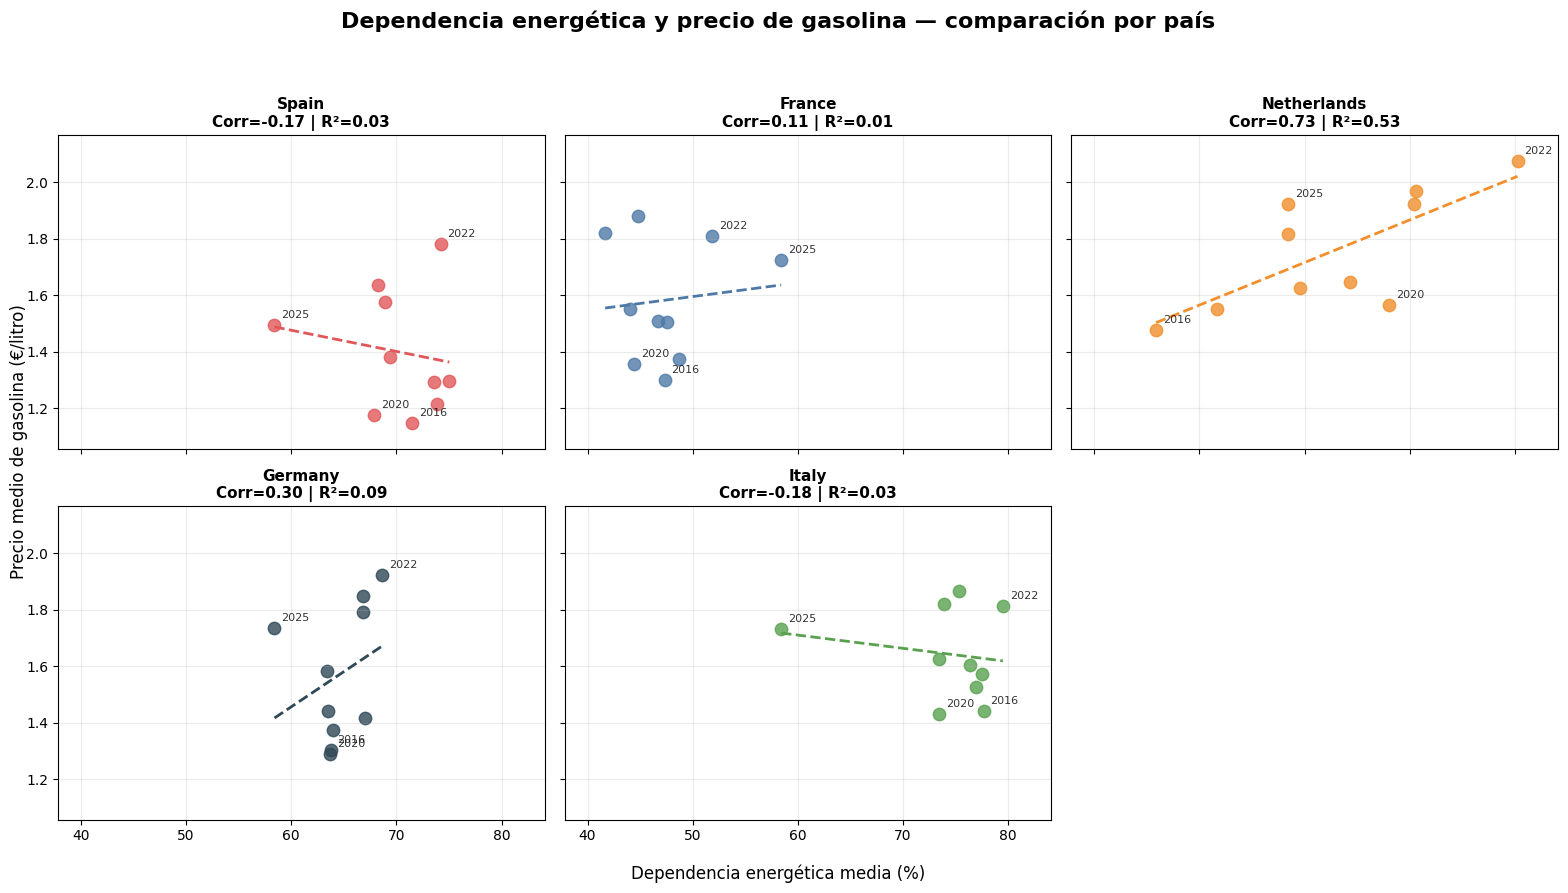

Tabla guardada en: outputs/tablas/q8_resumen_dependencia_precio_gasolina_5_paises.csv


,pais,n_anios,correlacion,r2,dependencia_media,precio_medio,precio_min,precio_max
0,Spain,10,-0.173,0.030,70.10,1.400,1.149,1.781
1,France,10,0.109,0.012,47.55,1.583,1.301,1.881
2,Netherlands,10,0.727,0.529,62.75,1.757,1.477,2.074
3,Germany,10,0.303,0.092,64.60,1.571,1.289,1.923
4,Italy,10,-0.176,0.031,74.25,1.644,1.432,1.866


In [24]:
# Pregunta 8 — Dependencia energética vs precio de gasolina
# Versión ordenada: una gráfica por país

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import builtins

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

os.makedirs("outputs/graficos", exist_ok=True)
os.makedirs("outputs/tablas", exist_ok=True)

# Países seleccionados
paises_q8 = ["Spain", "France", "Netherlands", "Germany", "Italy"]

# Base: gasolina, últimos 10 años disponibles
q8 = base_anual[
    (base_anual["nombre_es"] == "Gasolina") &
    (base_anual["country_name"].isin(paises_q8)) &
    (base_anual["anio"].isin(ultimos_10))
].copy()

# Aseguramos tipos numéricos
q8["anio"] = pd.to_numeric(q8["anio"], errors="coerce")
q8["precio_medio"] = pd.to_numeric(q8["precio_medio"], errors="coerce")
q8["dependencia_energetica_media"] = pd.to_numeric(
    q8["dependencia_energetica_media"],
    errors="coerce"
)

# Quitamos nulos
q8 = q8.dropna(subset=[
    "anio",
    "country_name",
    "precio_medio",
    "dependencia_energetica_media"
]).copy()

q8["anio"] = q8["anio"].astype(int)

# Guardamos la tabla base
guardar_tabla(
    q8,
    "q8_dependencia_precio_gasolina_5_paises_ultimos_10_anios.csv"
)

# Colores por país
colores_paises = {
    "Spain": "#E15759",
    "France": "#4E79A7",
    "Netherlands": "#F28E2B",
    "Germany": "#2F4858",
    "Italy": "#59A14F"
}

# Resumen estadístico por país
resumen_q8 = []

# Rango común para que las mini-gráficas sean comparables
x_min = q8["dependencia_energetica_media"].min()
x_max = q8["dependencia_energetica_media"].max()
y_min = q8["precio_medio"].min()
y_max = q8["precio_medio"].max()

margen_x = (x_max - x_min) * 0.10
margen_y = (y_max - y_min) * 0.10

# Creamos figura 2x3
fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharex=True, sharey=True)
axes = axes.flatten()

for i, pais in enumerate(paises_q8):
    ax = axes[i]
    datos = q8[q8["country_name"] == pais].sort_values("anio").copy()

    color = colores_paises.get(pais, "#4E79A7")

    if len(datos) < 2:
        ax.set_title(f"{pais}\nSin datos suficientes")
        ax.axis("off")
        continue

    X = datos[["dependencia_energetica_media"]].values
    y = datos["precio_medio"].values

    modelo = LinearRegression()
    modelo.fit(X, y)
    y_pred = modelo.predict(X)

    corr = datos["dependencia_energetica_media"].corr(datos["precio_medio"])
    r2 = r2_score(y, y_pred)

    resumen_q8.append({
        "pais": pais,
        "n_anios": len(datos),
        "correlacion": builtins.round(float(corr), 3),
        "r2": builtins.round(float(r2), 3),
        "dependencia_media": builtins.round(float(datos["dependencia_energetica_media"].mean()), 2),
        "precio_medio": builtins.round(float(datos["precio_medio"].mean()), 3),
        "precio_min": builtins.round(float(datos["precio_medio"].min()), 3),
        "precio_max": builtins.round(float(datos["precio_medio"].max()), 3)
    })

    # Puntos
    ax.scatter(
        datos["dependencia_energetica_media"],
        datos["precio_medio"],
        s=80,
        color=color,
        alpha=0.80
    )

    # Línea de regresión
    x_linea = np.linspace(
        datos["dependencia_energetica_media"].min(),
        datos["dependencia_energetica_media"].max(),
        100
    )

    y_linea = modelo.predict(x_linea.reshape(-1, 1))

    ax.plot(
        x_linea,
        y_linea,
        linestyle="--",
        linewidth=2,
        color=color
    )

    # Etiquetamos solo años clave para no ensuciar
    anios_clave = [
        datos["anio"].min(),
        2020,
        2022,
        datos["anio"].max()
    ]

    for _, row in datos.iterrows():
        if int(row["anio"]) in anios_clave:
            ax.annotate(
                int(row["anio"]),
                (row["dependencia_energetica_media"], row["precio_medio"]),
                fontsize=8,
                xytext=(5, 5),
                textcoords="offset points",
                alpha=0.8
            )

    # Título de cada mini-gráfica con estadística
    ax.set_title(
        f"{pais}\nCorr={corr:.2f} | R²={r2:.2f}",
        fontsize=11,
        fontweight="bold"
    )

    ax.grid(True, alpha=0.25)
    ax.set_xlim(x_min - margen_x, x_max + margen_x)
    ax.set_ylim(y_min - margen_y, y_max + margen_y)

# Quitamos el subplot vacío si sobra
axes[-1].axis("off")

# Títulos generales
fig.suptitle(
    "Dependencia energética y precio de gasolina — comparación por país",
    fontsize=16,
    fontweight="bold"
)

fig.supxlabel("Dependencia energética media (%)", fontsize=12)
fig.supylabel("Precio medio de gasolina (€/litro)", fontsize=12)

plt.tight_layout(rect=[0, 0, 1, 0.94])

guardar_grafico("q8_dependencia_precio_gasolina_small_multiples.png")
plt.show()

# Tabla resumen
resumen_q8_df = pd.DataFrame(resumen_q8)

guardar_tabla(
    resumen_q8_df,
    "q8_resumen_dependencia_precio_gasolina_5_paises.csv"
)

resumen_q8_df

### Interpretación de resultados

El resumen muestra relaciones muy diferentes por país. España presenta una correlación débil y negativa, alrededor de **-0,173**, con un **R² de 0,030**. Francia también muestra una relación muy baja. Países Bajos, en cambio, presenta una correlación más alta, cerca de **0,727**, y un **R² de 0,529**.

La conclusión no es que la dependencia energética “determine” el precio, sino que su relación depende del país. Esto tiene sentido: cada mercado tiene una estructura energética distinta, diferentes fuentes de suministro, distinta fiscalidad y diferentes medidas públicas. Por eso la dependencia energética sirve para contextualizar vulnerabilidad, pero no sustituye al análisis de precios, impuestos y mercado.


## Pregunta 8B — Dependencia energética previa y subida tras el shock de 2022

**Pregunta reflexiva:** ¿Los países más dependientes energéticamente antes de 2022 sufrieron mayores subidas del precio de la gasolina después del shock energético?

**Hipótesis:** podría esperarse una relación positiva, porque una mayor dependencia exterior puede aumentar la exposición a tensiones de suministro. Sin embargo, el impacto final también depende de impuestos, ayudas públicas, contratos, refino y diversificación de proveedores.

**Idea del gráfico:** en lugar de comparar dependencia y precio año a año, se comparan dos periodos: 2019-2021 como etapa previa y 2022 en adelante como etapa posterior. El eje X mide dependencia energética previa y el eje Y la subida porcentual del precio.

**Operación relacionada:** comparación pre/post shock por país y región.


Periodo pre-shock: [2019, 2020, 2021]
Periodo post-shock: [2022, 2023, 2024, 2025]
Tabla guardada en: outputs/tablas/grafico_dependencia_shock_2022_gasolina_paises.csv


,country_name,region_europa,dependencia_pre_2022,precio_pre_2022,precio_post_2022,subida_precio_eur_litro,subida_precio_pct
0,Austria,Occidental,60.611333,1.201750,1.602644,0.400893,33.359100
22,Romania,Este,30.041000,1.090337,1.449401,0.359064,32.931517
15,Latvia,Este,42.579000,1.246779,1.651435,0.404656,32.456095
2,Bulgaria,Este,37.602000,1.030433,1.337455,0.307022,29.795461
17,Luxembourg,Occidental,93.241667,1.206716,1.565606,0.358890,29.741029
12,Hungary,Este,60.150333,1.143434,1.472516,0.329082,28.780120
5,Czechia,Este,39.845333,1.197215,1.541164,0.343949,28.729135
20,Poland,Este,42.830000,1.121171,1.434208,0.313036,27.920474
16,Lithuania,Este,74.461000,1.193820,1.526225,0.332404,27.843730
10,Germany,Occidental,64.708667,1.429275,1.825479,0.396204,27.720663


Correlación dependencia pre-2022 - subida precio: -0.347
R²: 0.12
Gráfico guardado en: outputs/graficos/grafico_dependencia_shock_2022_gasolina.png


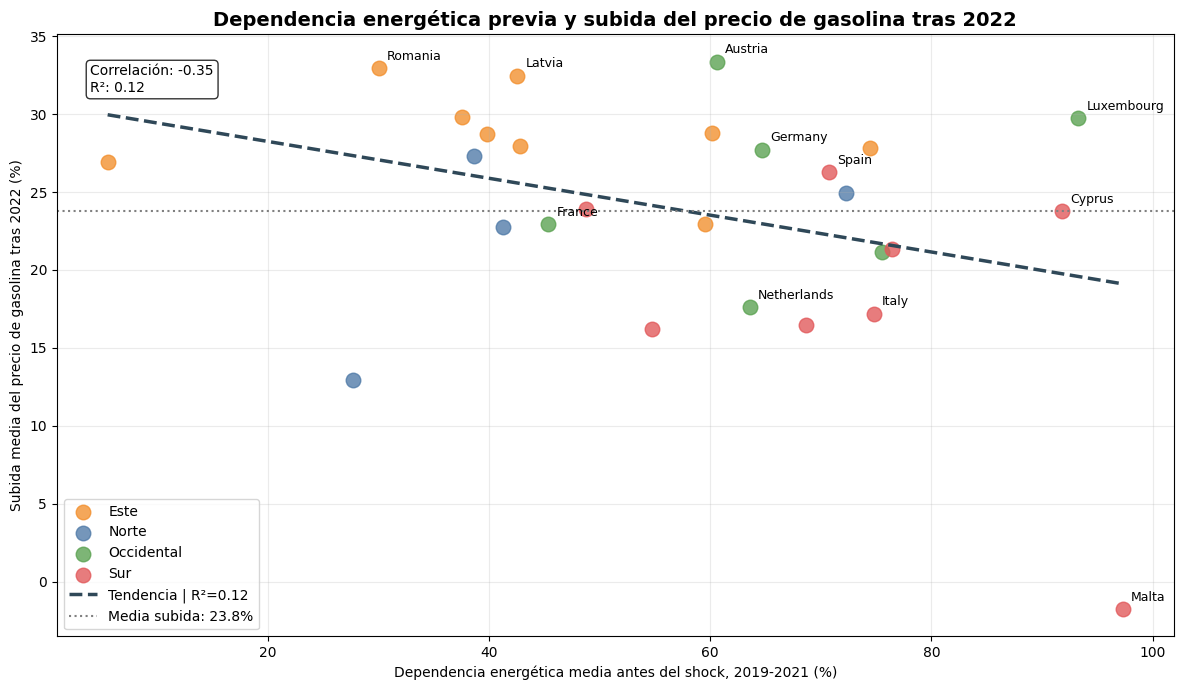

In [25]:
# PREGUNTA DEPENDENCIA — Dependencia energética previa al shock vs subida de precio tras 2022
# Gráfico tipo "riesgo energético": X = dependencia media pre-2022, Y = subida % del precio de gasolina post-2022

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import builtins

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

os.makedirs("outputs/graficos", exist_ok=True)
os.makedirs("outputs/tablas", exist_ok=True)

# ------------------------------------------------------------
# 1. Base: gasolina + dependencia energética
# ------------------------------------------------------------

dep_base = base_anual[
    base_anual["nombre_es"] == "Gasolina"
].copy()

dep_base["anio"] = pd.to_numeric(dep_base["anio"], errors="coerce")
dep_base["precio_medio"] = pd.to_numeric(dep_base["precio_medio"], errors="coerce")
dep_base["dependencia_energetica_media"] = pd.to_numeric(
    dep_base["dependencia_energetica_media"],
    errors="coerce"
)

dep_base = dep_base.dropna(subset=[
    "country_name",
    "anio",
    "precio_medio",
    "dependencia_energetica_media"
]).copy()

dep_base["anio"] = dep_base["anio"].astype(int)

# Periodos:
# Pre-shock: 2019-2021
# Post-shock: 2022 hasta último año disponible
pre_years = [2019, 2020, 2021]

ultimo_anio_dep = int(dep_base["anio"].max())
post_years = list(range(2022, ultimo_anio_dep + 1))

print("Periodo pre-shock:", pre_years)
print("Periodo post-shock:", post_years)

pre = dep_base[
    dep_base["anio"].isin(pre_years)
].groupby("country_name", as_index=False).agg({
    "precio_medio": "mean",
    "dependencia_energetica_media": "mean"
}).rename(columns={
    "precio_medio": "precio_pre_2022",
    "dependencia_energetica_media": "dependencia_pre_2022"
})

post = dep_base[
    dep_base["anio"].isin(post_years)
].groupby("country_name", as_index=False).agg({
    "precio_medio": "mean",
    "dependencia_energetica_media": "mean"
}).rename(columns={
    "precio_medio": "precio_post_2022",
    "dependencia_energetica_media": "dependencia_post_2022"
})

shock = pre.merge(
    post,
    on="country_name",
    how="inner"
)

shock["subida_precio_pct"] = (
    (shock["precio_post_2022"] - shock["precio_pre_2022"]) /
    shock["precio_pre_2022"]
) * 100

shock["subida_precio_eur_litro"] = (
    shock["precio_post_2022"] - shock["precio_pre_2022"]
)

# Quitamos valores imposibles
shock = shock[
    (shock["precio_pre_2022"] > 0) &
    (shock["precio_post_2022"] > 0) &
    (shock["dependencia_pre_2022"] > 0)
].copy()

# ------------------------------------------------------------
# 2. Añadimos regiones manuales para dar lectura geopolítica
# ------------------------------------------------------------

region_map = {
    # Sur
    "Spain": "Sur",
    "Portugal": "Sur",
    "Italy": "Sur",
    "Greece": "Sur",
    "Malta": "Sur",
    "Cyprus": "Sur",
    "Croatia": "Sur",
    "Slovenia": "Sur",

    # Norte
    "Denmark": "Norte",
    "Sweden": "Norte",
    "Finland": "Norte",
    "Ireland": "Norte",

    # Occidental
    "Germany": "Occidental",
    "France": "Occidental",
    "Netherlands": "Occidental",
    "Belgium": "Occidental",
    "Austria": "Occidental",
    "Luxembourg": "Occidental",

    # Este
    "Poland": "Este",
    "Czechia": "Este",
    "Czech Republic": "Este",
    "Slovak Republic": "Este",
    "Slovakia": "Este",
    "Hungary": "Este",
    "Romania": "Este",
    "Bulgaria": "Este",
    "Estonia": "Este",
    "Latvia": "Este",
    "Lithuania": "Este"
}

shock["region_europa"] = shock["country_name"].map(region_map).fillna("Otros")

guardar_tabla(
    shock,
    "grafico_dependencia_shock_2022_gasolina_paises.csv"
)

display(
    shock[[
        "country_name",
        "region_europa",
        "dependencia_pre_2022",
        "precio_pre_2022",
        "precio_post_2022",
        "subida_precio_eur_litro",
        "subida_precio_pct"
    ]].sort_values("subida_precio_pct", ascending=False)
)

# ------------------------------------------------------------
# 3. Regresión: dependencia pre-2022 vs subida de precio tras 2022
# ------------------------------------------------------------

X = shock[["dependencia_pre_2022"]].values
y = shock["subida_precio_pct"].values

modelo_dep = LinearRegression()
modelo_dep.fit(X, y)

y_pred = modelo_dep.predict(X)

corr_dep = shock["dependencia_pre_2022"].corr(shock["subida_precio_pct"])
r2_dep = r2_score(y, y_pred)

print("Correlación dependencia pre-2022 - subida precio:", builtins.round(float(corr_dep), 3))
print("R²:", builtins.round(float(r2_dep), 3))

# ------------------------------------------------------------
# 4. Gráfico: riesgo energético ante shock
# ------------------------------------------------------------

colores_region = {
    "Sur": "#E15759",
    "Norte": "#4E79A7",
    "Occidental": "#59A14F",
    "Este": "#F28E2B",
    "Otros": "#9C755F"
}

plt.figure(figsize=(12, 7))

for region, datos_region in shock.groupby("region_europa"):
    plt.scatter(
        datos_region["dependencia_pre_2022"],
        datos_region["subida_precio_pct"],
        s=110,
        alpha=0.78,
        color=colores_region.get(region, "#9C755F"),
        label=region
    )

# Línea de regresión
xline = np.linspace(
    shock["dependencia_pre_2022"].min(),
    shock["dependencia_pre_2022"].max(),
    200
)

plt.plot(
    xline,
    modelo_dep.predict(xline.reshape(-1, 1)),
    linestyle="--",
    linewidth=2.5,
    color="#2F4858",
    label=f"Tendencia | R²={r2_dep:.2f}"
)

# Etiquetamos países clave y outliers
paises_clave = ["Spain", "Germany", "France", "Italy", "Netherlands"]
top_shock = shock.nlargest(3, "subida_precio_pct")["country_name"].tolist()
top_dep = shock.nlargest(3, "dependencia_pre_2022")["country_name"].tolist()

paises_label = list(set(paises_clave + top_shock + top_dep))

for _, row in shock.iterrows():
    if row["country_name"] in paises_label:
        plt.annotate(
            row["country_name"],
            (row["dependencia_pre_2022"], row["subida_precio_pct"]),
            fontsize=9,
            xytext=(6, 6),
            textcoords="offset points"
        )

plt.axhline(
    shock["subida_precio_pct"].mean(),
    color="gray",
    linestyle=":",
    linewidth=1.5,
    label=f"Media subida: {shock['subida_precio_pct'].mean():.1f}%"
)

plt.text(
    0.03,
    0.95,
    f"Correlación: {corr_dep:.2f}\nR²: {r2_dep:.2f}",
    transform=plt.gca().transAxes,
    fontsize=10,
    va="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.80)
)

plt.title(
    "Dependencia energética previa y subida del precio de gasolina tras 2022",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Dependencia energética media antes del shock, 2019-2021 (%)")
plt.ylabel(f"Subida media del precio de gasolina tras 2022 (%)")
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()

guardar_grafico("grafico_dependencia_shock_2022_gasolina.png")
plt.show()

### Interpretación de resultados

El gráfico obtiene una **correlación aproximada de -0,347** y un **R² de 0,12**. Esto indica que, en este conjunto de datos, la dependencia energética previa no explica por sí sola la subida posterior del precio de gasolina. La relación incluso aparece negativa, aunque con poder explicativo bajo.

La lectura analítica es interesante: el shock de 2022 fue europeo, pero su impacto no dependió únicamente de la dependencia agregada. Influyeron la composición de importaciones, la exposición a Rusia, las medidas públicas de contención, la fiscalidad, el mercado mayorista, el refino y la logística. Por eso este gráfico ayuda a matizar la hipótesis inicial: mayor dependencia no siempre implica automáticamente mayor subida de gasolina.


## Pregunta 9 — Precio real vs precio predicho

**Pregunta reflexiva:** ¿Podemos estimar razonablemente el precio del carburante usando variables del cubo?

**Hipótesis:** un modelo con año, producto, región, PIB, dependencia e impuestos debería explicar una parte del precio, pero no todo. Hay factores externos no incluidos, como petróleo, tipo de cambio, márgenes, competencia y medidas regulatorias.

**Idea del gráfico:** se entrena una regresión múltiple. En el eje X está el precio real y en el eje Y el precio predicho. La diagonal representa predicción perfecta.

**Explicación sencilla:** si un punto cae cerca de la diagonal, el modelo ha acertado bastante. Si cae lejos, el modelo se equivoca. El MAE indica el error medio en €/litro.


Observaciones modelo: 540 | R² test: 0.476 | MAE: 0.146 €/l
Tabla guardada en: outputs/tablas/q9_precio_real_vs_predicho.csv
Gráfico guardado en: outputs/graficos/q9_precio_real_vs_predicho.png


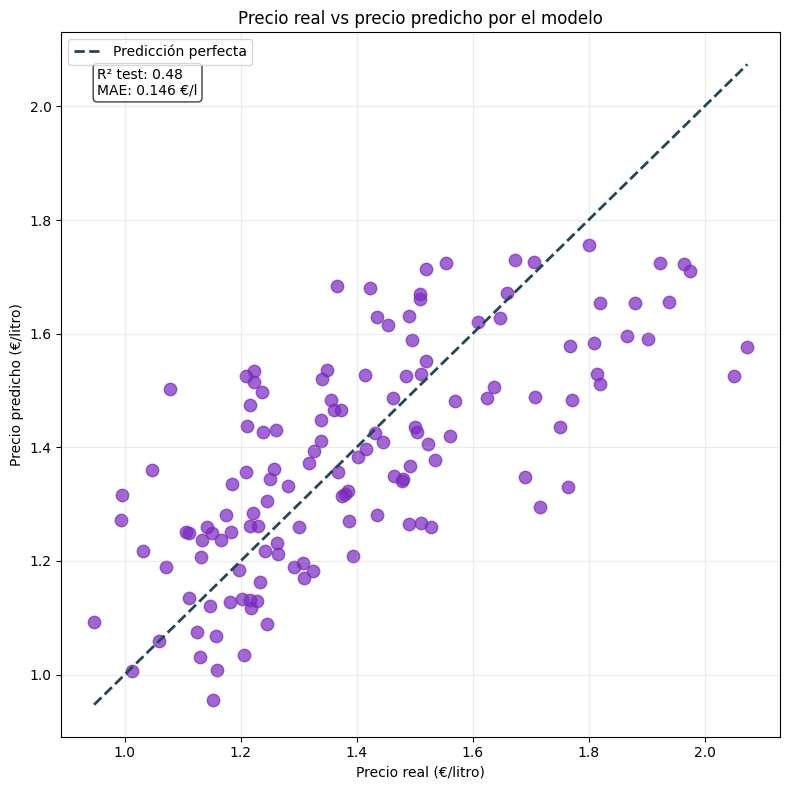

Tabla guardada en: outputs/tablas/q9_coeficientes_modelo_regresion.csv


,variable,coeficiente
1,impuesto_medio,10.465634
6,region_4_Occidental,0.204567
7,region_4_Sur,0.184907
5,region_4_Norte,0.160897
0,anio,0.053866
3,pib_modelo,0.000002
2,dependencia_energetica_media,-0.001646
4,nombre_es_Gasóleo,-0.053212


Interpretación: la diagonal es la predicción perfecta; cuanto más cerca estén los puntos, mejor funciona el modelo. El MAE es el error medio en €/litro.


In [26]:
modelo_df = base_anual[(base_anual["anio"].isin(ultimos_10)) & (base_anual["nombre_es"].isin(["Gasolina","Gasóleo"]))].copy()
modelo_df["iso3"] = modelo_df["country_name"].map(mapa_iso3)
modelo_df = modelo_df.merge(pib_wb, on=["iso3","anio"], how="left")
modelo_df["pib_modelo"] = modelo_df["pib_per_capita_wb"]
if "pib_per_capita_medio" in modelo_df.columns:
    modelo_df["pib_modelo"] = modelo_df["pib_modelo"].fillna(modelo_df["pib_per_capita_medio"])
modelo_df = modelo_df.dropna(subset=["precio_medio","impuesto_medio","dependencia_energetica_media","pib_modelo"])
modelo_ml = pd.get_dummies(modelo_df[["precio_medio","anio","impuesto_medio","dependencia_energetica_media","pib_modelo","nombre_es","region_4"]], columns=["nombre_es","region_4"], drop_first=True)
X_cols = [c for c in modelo_ml.columns if c != "precio_medio"]
X = modelo_ml[X_cols]; y = modelo_ml["precio_medio"]
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.25,random_state=42)
model = LinearRegression().fit(X_train,y_train)
y_pred = model.predict(X_test)
r2 = r2_score(y_test,y_pred); mae = mean_absolute_error(y_test,y_pred)
print(f"Observaciones modelo: {len(modelo_ml)} | R² test: {r2:.3f} | MAE: {mae:.3f} €/l")
pred_df = pd.DataFrame({"precio_real":y_test.values,"precio_predicho":y_pred})
guardar_tabla(pred_df,"q9_precio_real_vs_predicho.csv")
plt.figure(figsize=(8,8))
plt.scatter(pred_df["precio_real"], pred_df["precio_predicho"], s=80, alpha=0.72, color=COL_PURPLE)
mn = min(pred_df.min()); mx = max(pred_df.max())
plt.plot([mn,mx],[mn,mx], linestyle="--", color=COL_DARK, linewidth=2, label="Predicción perfecta")
plt.text(0.05,0.95,f"R² test: {r2:.2f}\nMAE: {mae:.3f} €/l", transform=plt.gca().transAxes, va="top", bbox=dict(boxstyle="round", facecolor="white", alpha=0.75))
plt.title("Precio real vs precio predicho por el modelo")
plt.xlabel("Precio real (€/litro)")
plt.ylabel("Precio predicho (€/litro)")
plt.legend(); plt.tight_layout(); guardar_grafico("q9_precio_real_vs_predicho.png"); plt.show()
coef = pd.DataFrame({"variable":X_cols,"coeficiente":model.coef_}).sort_values("coeficiente", ascending=False)
guardar_tabla(coef,"q9_coeficientes_modelo_regresion.csv")
display(coef.head(15))
print("Interpretación: la diagonal es la predicción perfecta; cuanto más cerca estén los puntos, mejor funciona el modelo. El MAE es el error medio en €/litro.")

### Interpretación de resultados

El modelo trabaja con **540 observaciones**, obtiene un **R² de test de 0,476** y un **MAE de 0,146 €/litro**. Esto significa que el modelo explica una parte relevante, aunque no total, de la variación del precio. Un error medio de 0,146 €/litro es interpretable: en carburantes, diferencias de 10-15 céntimos por litro ya son económicamente visibles para el consumidor.

Los coeficientes impresos sugieren que el componente fiscal y la región tienen peso en la predicción, mientras que el PIB y la dependencia aportan contexto. La conclusión es equilibrada: el cubo permite modelizar el precio con cierta capacidad, pero faltan variables externas como Brent, tipo de cambio, márgenes de refino, competencia local y políticas temporales.


## Pregunta 10 — Antes de 2022 vs después de 2022 por región

**Pregunta reflexiva:** ¿El shock de 2022 desplazó al alza los precios de gasolina en todas las regiones europeas por igual?

**Hipótesis:** todas las regiones deberían subir después de 2022, pero no necesariamente con la misma intensidad. Las diferencias pueden venir de dependencia energética, fiscalidad, localización, capacidad de refino y medidas públicas.

**Idea del gráfico:** dumbbell chart por regiones. Cada línea conecta el precio medio antes de 2022 con el precio medio desde 2022.

**Operación relacionada:** comparación temporal por región.


Tabla guardada en: outputs/tablas/q10_antes_despues_2022_region_gasolina.csv


periodo,region_4,Antes de 2022,Desde 2022,incremento,incremento_pct
0,Este,1.174105,1.471469,0.297364,25.326856
3,Sur,1.310280,1.608078,0.297798,22.727815
2,Occidental,1.361666,1.742115,0.380450,27.940022
1,Norte,1.306057,1.742334,0.436276,33.404077


Gráfico guardado en: outputs/graficos/q10_dumbbell_antes_despues_2022_region.png


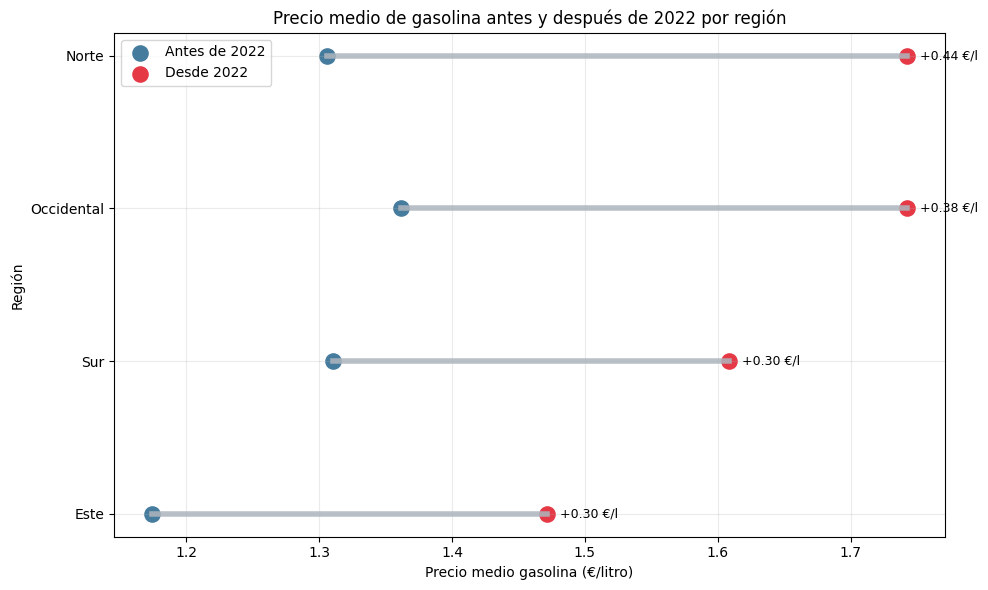

Interpretación: la región con mayor aumento absoluto es Norte.


In [27]:
q10 = base_anual[(base_anual["nombre_es"] == "Gasolina") & (base_anual["region_4"].isin(["Sur","Este","Norte","Occidental"]))].copy()
q10["periodo"] = np.where(q10["anio"] < 2022, "Antes de 2022", "Desde 2022")
reg = q10.groupby(["region_4","periodo"], as_index=False).agg({"precio_medio":"mean"})
wide = reg.pivot(index="region_4", columns="periodo", values="precio_medio").reset_index()
wide["incremento"] = wide["Desde 2022"] - wide["Antes de 2022"]
wide["incremento_pct"] = wide["incremento"] / wide["Antes de 2022"] * 100
wide = wide.sort_values("incremento", ascending=True)
guardar_tabla(wide,"q10_antes_despues_2022_region_gasolina.csv")
display(wide)
plt.figure(figsize=(10,6)); y_pos = np.arange(len(wide))
for i, row in enumerate(wide.itertuples()):
    plt.plot([row._2,row._3],[i,i],color=COL_GREY,linewidth=4,alpha=0.85)
    plt.scatter(row._2,i,color=COL_EU,s=120,label="Antes de 2022" if i==0 else "")
    plt.scatter(row._3,i,color=COL_SP,s=120,label="Desde 2022" if i==0 else "")
    plt.text(row._3+0.01,i,f"+{row.incremento:.2f} €/l",va="center",fontsize=9)
plt.yticks(y_pos,wide["region_4"]); plt.xlabel("Precio medio gasolina (€/litro)"); plt.ylabel("Región")
plt.title("Precio medio de gasolina antes y después de 2022 por región")
plt.legend(); plt.tight_layout(); guardar_grafico("q10_dumbbell_antes_despues_2022_region.png"); plt.show()
print(f"Interpretación: la región con mayor aumento absoluto es {wide.loc[wide['incremento'].idxmax(),'region_4']}.")

### Interpretación de resultados

La tabla muestra subidas en todas las regiones. La región **Norte** aparece con el mayor incremento absoluto, alrededor de **0,436 €/litro**, y una subida relativa de aproximadamente **33,4%**. Occidental también presenta un aumento fuerte, cercano a **0,380 €/litro**.

La lectura de negocio es que 2022 no fue una anomalía aislada de un país, sino un cambio de nivel en el mercado europeo. Las diferencias regionales pueden explicarse por distinta estructura fiscal, costes, exposición energética, medidas nacionales y composición del mercado. El gráfico es útil porque resume el shock en una visualización directa: antes y después.


# 9. Gráficas regionales complementarias

Estas gráficas amplían la lectura regional. No sustituyen a las preguntas principales, pero ayudan a explicar el comportamiento territorial del precio en Europa.


## Regional A — Incremento post-2022 por región y producto

**Pregunta reflexiva:** ¿El impacto posterior a 2022 fue igual para gasolina y gasóleo dentro de cada región?

**Hipótesis:** ambos productos deberían subir, pero la intensidad puede variar por demanda, fiscalidad y disponibilidad de refinados.

**Idea del gráfico:** heatmap de incremento post-2022 por región y producto.


Tabla guardada en: outputs/tablas/q11_incremento_post2022_region_producto.csv
Gráfico guardado en: outputs/graficos/q11_heatmap_incremento_post2022_region_producto.png


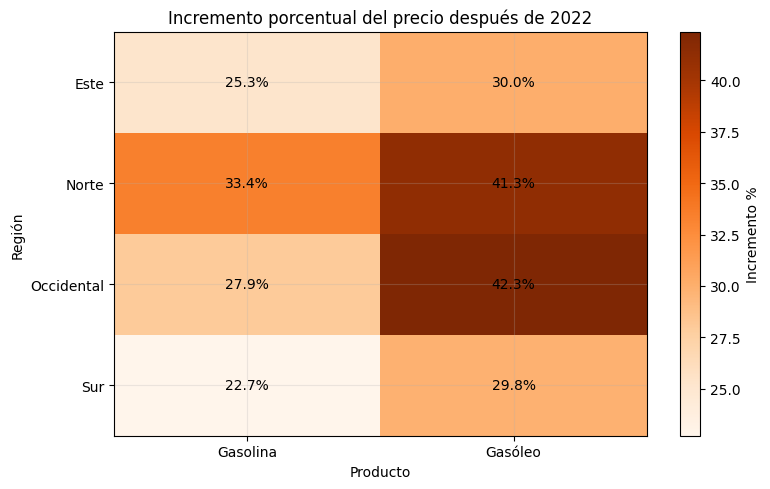

In [28]:
q11 = base_anual[(base_anual["nombre_es"].isin(["Gasolina","Gasóleo"])) & (base_anual["region_4"].isin(["Sur","Este","Norte","Occidental"]))].copy()
q11["periodo"] = np.where(q11["anio"] < 2022, "Antes", "Después")
pp = q11.groupby(["region_4","nombre_es","periodo"], as_index=False).agg({"precio_medio":"mean"})
wd = pp.pivot_table(index=["region_4","nombre_es"], columns="periodo", values="precio_medio").reset_index()
wd["incremento_pct"] = (wd["Después"] - wd["Antes"]) / wd["Antes"] * 100
heat = wd.pivot(index="region_4", columns="nombre_es", values="incremento_pct")
guardar_tabla(wd,"q11_incremento_post2022_region_producto.csv")
plt.figure(figsize=(8,5)); im=plt.imshow(heat,aspect="auto",cmap="Oranges"); plt.colorbar(im,label="Incremento %")
plt.xticks(range(len(heat.columns)),heat.columns); plt.yticks(range(len(heat.index)),heat.index)
for i in range(len(heat.index)):
    for j in range(len(heat.columns)):
        plt.text(j,i,f"{heat.iloc[i,j]:.1f}%",ha="center",va="center")
plt.title("Incremento porcentual del precio después de 2022"); plt.xlabel("Producto"); plt.ylabel("Región")
plt.tight_layout(); guardar_grafico("q11_heatmap_incremento_post2022_region_producto.png"); plt.show()

### Interpretación de resultados

Este heatmap permite ver si la subida posterior a 2022 se concentra más en gasolina o gasóleo y qué regiones se ven más afectadas. Si ambos productos suben en todas las regiones, la causa parece común. Si un producto sube mucho más, puede haber factores específicos de demanda, refino o fiscalidad.


## Regional B — Ranking dinámico de regiones

**Pregunta reflexiva:** ¿Qué región ocupa sistemáticamente los puestos más caros en gasolina?

**Hipótesis:** las regiones no deberían alternarse al azar; algunas tenderán a aparecer recurrentemente como más caras por factores estructurales.

**Idea del gráfico:** bump chart que muestra cómo cambia el ranking regional durante los últimos 10 años.


Tabla guardada en: outputs/tablas/q12_ranking_regional_gasolina_ultimos_10_anios.csv
Gráfico guardado en: outputs/graficos/q12_bump_chart_ranking_regional_gasolina.png


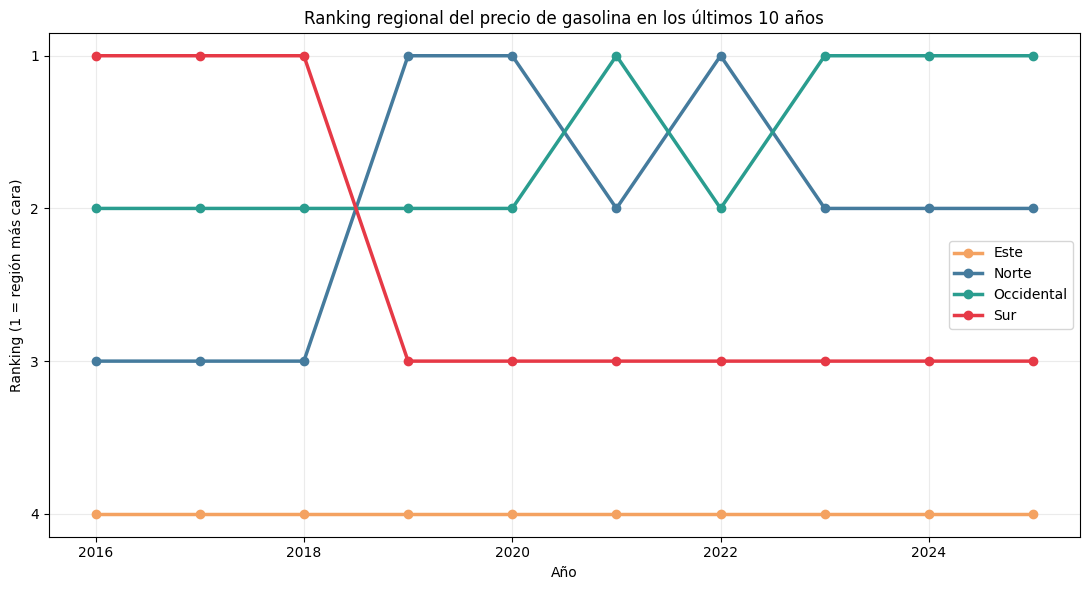

In [29]:
q12 = base_anual[(base_anual["nombre_es"]=="Gasolina") & (base_anual["region_4"].isin(["Sur","Este","Norte","Occidental"])) & (base_anual["anio"].isin(ultimos_10))].groupby(["anio","region_4"],as_index=False).agg({"precio_medio":"mean"})
q12["ranking"] = q12.groupby("anio")["precio_medio"].rank(ascending=False, method="dense")
guardar_tabla(q12,"q12_ranking_regional_gasolina_ultimos_10_anios.csv")
plt.figure(figsize=(11,6)); region_colors={"Sur":COL_SP,"Este":COL_ACCENT,"Norte":COL_EU,"Occidental":COL_GREEN}
for region,d in q12.groupby("region_4"):
    d=d.sort_values("anio"); plt.plot(d["anio"],d["ranking"],marker="o",linewidth=2.5,color=region_colors.get(region,COL_GREY),label=region)
plt.gca().invert_yaxis(); plt.yticks([1,2,3,4]); plt.title("Ranking regional del precio de gasolina en los últimos 10 años")
plt.xlabel("Año"); plt.ylabel("Ranking (1 = región más cara)"); plt.legend(); plt.tight_layout(); guardar_grafico("q12_bump_chart_ranking_regional_gasolina.png"); plt.show()

### Interpretación de resultados

El bump chart permite ver cambios de posición entre regiones. Si una región se mantiene arriba, el precio alto parece estructural. Si cambia de puesto tras 2022, puede indicar que el shock energético alteró el equilibrio anterior.


## Regional C — Boxplot por región antes y después de 2022

**Pregunta reflexiva:** ¿Cambió toda la distribución de precios después de 2022 o solo subieron algunos valores extremos?

**Hipótesis:** si el shock fue general, las cajas posteriores a 2022 deberían desplazarse hacia arriba, no solo aparecer outliers aislados.

**Idea del gráfico:** boxplot por región y periodo. Compara la distribución completa del precio de gasolina antes y después de 2022.


Tabla guardada en: outputs/tablas/q14_boxplot_region_periodo_gasolina.csv
Gráfico guardado en: outputs/graficos/q14_boxplot_region_periodo_gasolina.png


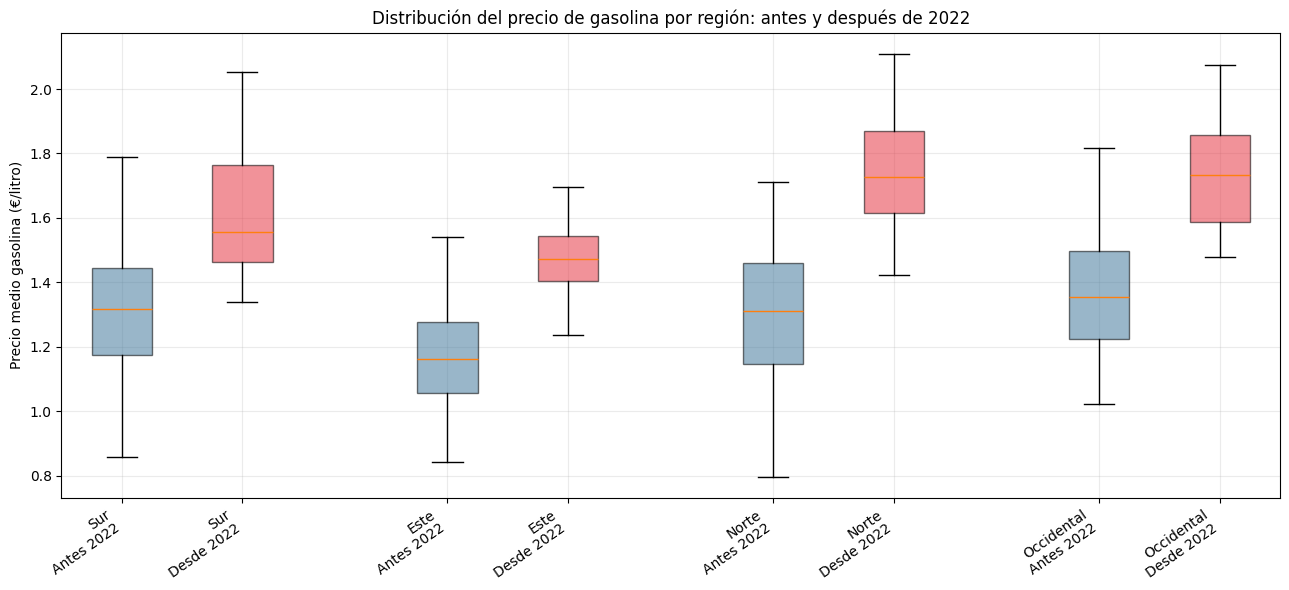

Interpretación: si las cajas posteriores a 2022 están más arriba, la distribución completa de precios se desplazó al alza.


In [30]:
q14 = base_anual[(base_anual["nombre_es"]=="Gasolina") & (base_anual["region_4"].isin(["Sur","Este","Norte","Occidental"]))].copy()
q14["periodo"] = np.where(q14["anio"] < 2022, "Antes de 2022", "Desde 2022")
guardar_tabla(q14,"q14_boxplot_region_periodo_gasolina.csv")
regiones=["Sur","Este","Norte","Occidental"]; data=[]; positions=[]; labels=[]; pos=1
for r in regiones:
    for per in ["Antes de 2022","Desde 2022"]:
        vals=q14[(q14["region_4"]==r)&(q14["periodo"]==per)]["precio_medio"].dropna().values
        data.append(vals); positions.append(pos); labels.append(f"{r}\n{per.replace(' de ', ' ')}"); pos+=1
    pos+=0.7
plt.figure(figsize=(13,6)); bp=plt.boxplot(data,positions=positions,patch_artist=True,showfliers=True)
for i,b in enumerate(bp["boxes"]): b.set(facecolor=COL_EU if i%2==0 else COL_SP, alpha=0.55)
plt.xticks(positions,labels,rotation=35,ha="right"); plt.title("Distribución del precio de gasolina por región: antes y después de 2022")
plt.ylabel("Precio medio gasolina (€/litro)"); plt.tight_layout(); guardar_grafico("q14_boxplot_region_periodo_gasolina.png"); plt.show()
print("Interpretación: si las cajas posteriores a 2022 están más arriba, la distribución completa de precios se desplazó al alza.")

### Interpretación de resultados

El boxplot muestra si el cambio posterior a 2022 afecta a toda la distribución. Si la mediana y la caja suben, el encarecimiento fue generalizado. Si solo aparecen puntos extremos, el efecto sería más puntual. Esta visualización completa la lectura del dumbbell, porque no solo compara medias, sino dispersión y valores extremos.


# 10. Conclusiones finales del cuaderno

1. **España se sitúa por debajo de la media europea** en el último año disponible y queda fuera del top 10 de gasolina más cara. Esto sugiere que, dentro de Europa, España no aparece como uno de los mercados más caros.

2. **El shock de 2022 es visible en varias visualizaciones.** La subida aparece tanto en series temporales como en comparaciones regionales antes/después. Esto refuerza la idea de que el precio de los carburantes responde a shocks internacionales y no solo a características nacionales.

3. **La gasolina y el gasóleo en España se mueven de forma parecida**, pero la brecha entre ambos no es constante. La diferencia depende de demanda, fiscalidad, refino, logística y condiciones de mercado.

4. **La fiscalidad es clave para entender el precio final.** Los gráficos de composición muestran que una parte muy importante del precio de un litro de gasolina en España corresponde a impuestos. Por eso no se debe interpretar el precio final como simple reflejo del petróleo.

5. **El PIB per cápita tiene relación positiva con el precio, pero limitada.** La regresión PIB-precio presenta una correlación positiva moderada y un R² bajo, por lo que el PIB ayuda a contextualizar, pero no explica por sí solo el precio.

6. **La dependencia energética no explica de manera uniforme el precio de gasolina.** En algunos países muestra relación, pero en otros apenas explica la variación. Esto confirma que la dependencia energética es una variable de contexto, no una causa única.

7. **El modelo de regresión múltiple mejora la explicación**, pero no predice perfectamente. El precio real depende de variables que el cubo recoge parcialmente y de otras externas como Brent, tipo de cambio, competencia, márgenes y política fiscal.

8. **El cubo dimensional cumple su función:** permite pasar de datos finales limpios a análisis de negocio con filtros, agregaciones, rankings, comparaciones temporales y modelos sencillos.


In [31]:
print("CUADERNO COMPLETADO")
print("Filas del cubo:", cubo.count())
print("Periodo analizado:", primer_anio, "-", ultimo_anio)
print("Países analizados:", base_anual["country_name"].nunique())
print("Productos analizados:", sorted(base_anual["nombre_es"].unique()))
print("Gráficas guardadas en outputs/graficos/")
print("Tablas guardadas en outputs/tablas/")

CUADERNO COMPLETADO
Filas del cubo: 55093
Periodo analizado: 2005 - 2025
Países analizados: 27
Productos analizados: ['Gasolina', 'Gasóleo']
Gráficas guardadas en outputs/graficos/
Tablas guardadas en outputs/tablas/


# 11. Referencias de contexto

Estas referencias se han utilizado para contextualizar las interpretaciones económicas y geopolíticas del análisis:

- **European Commission — Weekly Oil Bulletin.** Publica precios de productos petrolíferos con y sin impuestos, IVA e impuestos especiales en países europeos.  
  https://energy.ec.europa.eu/data-and-analysis/weekly-oil-bulletin_en

- **Council of the European Union — EU response to the 2022 energy crisis.** Explica que la invasión rusa de Ucrania en 2022 impactó en el mercado energético y elevó los precios a niveles récord.  
  https://www.consilium.europa.eu/en/policies/how-did-the-eu-respond-to-the-2022-energy-crisis/

- **Eurostat — EU imports of energy products.** Señala que hasta finales de 2021 Rusia era el principal proveedor de petróleo y gas natural de la UE, y muestra el cambio posterior en los flujos energéticos.  
  https://ec.europa.eu/eurostat/statistics-explained/index.php?title=EU_imports_of_energy_products_-_latest_developments

- **IEA — Russia's war on Ukraine.** Contextualiza los recortes de suministro energético ruso y la crisis energética europea.  
  https://www.iea.org/topics/russias-war-on-ukraine

- **European Commission — Excise duties on energy.** Explica la estructura de impuestos especiales sobre productos energéticos y los mínimos armonizados en la UE.  
  https://taxation-customs.ec.europa.eu/taxation/excise-duties/excise-duties-energy_en
